# Noise Detection DINO v3

Focused notebook for the current signal-detection path. The retained flow rebuilds the SNR sweep, inspects the fixed end-to-end pipeline, and compares the baseline agreement map against the final multilevel + gap output without the old support-mask branches or sweep-only diagnostics.


## End-to-End Pipeline

1. Load the configured SigMF or USRP chunk and build the exact spectrogram image fed to DINO.
2. Generate normalized DINO, power, and texture score maps from that same image.
3. Form the baseline agreement map as the geometric mean of the DINO and power maps.
4. Estimate texture reliability from texture peakiness, speckle behavior, and agreement overlap.
5. Derive dynamic strong, mid, low, and structure thresholds from that reliability score.
6. Build the low-pass candidate directly from agreement clearing the low threshold so the relaxed path lets nearly everything through.
7. Use the structure diagnostic as a clean-capture test: when it stays smooth and low-speckle, let the texture activations pass through nearly unchanged.
8. Combine the clean-pass texture term with the strong, mid, and low D+P candidate contributions.
9. Only deweight texture when the structure diagnostic becomes speckly, then normalize the final score map.
10. Threshold the final map once at a fixed operating point and smooth the label map for the final mask.

## Filtering Steps

1. Agreement low-threshold gate.
2. Structure-clean texture pass-through with speckle-driven texture deweighting.
3. Final fixed threshold plus binary smoothing and component cleanup.

This notebook temporarily bypasses the structure threshold gate, the power-rescue gate, and candidate-level minimum-component cleanup so the low-threshold agreement path stays open while clean captures can carry texture directly.

## Working Cells

Run order: setup cells, SNR sweep cells, contribution review cells, then the fixed pipeline comparison cell.

This notebook now excludes the support-mask views, parameter sweeps, and the low-candidate debug sweep so the remaining cells track the main path only.


In [19]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage, signal
import torch
import torchvision.transforms as T
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

SIGMF_META_PATH = '/home/sat3737/holoscan_demo_workspace/test_data/SIGINT_DAY_DEMO_all_16_Emitter_noNoise.sigmf-meta'
#SIGMF_META_PATH= '/home/sat3737/holoscan_demo_workspace/test_data/DJI_mavic_mini_2G.sigmf-meta'
DINOV3_LOCATION = '/home/sat3737/holoscan_demo_workspace/dinov3'
MODEL_NAME = 'dinov3_vitb16'
WEIGHTS_PATH = '/home/sat3737/holoscan_demo_workspace/dinov3/weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'

FFT_SIZE = 1024
NOVERLAP = 512
SAMPLE_OFFSET_S = 0.1090
DEFAULT_CHUNK_SECONDS = 1.0
USRP_SPECTROGRAM_DIR = '/tmp/usrp_spectrograms'

DATA_SOURCE = 'tensor_npy'
USE_USRP_CHUNK_DURATION = True
USE_USRP_SHAPE_MATCH = True

DEFAULT_TENSOR_DIR = Path('/tmp/usrp_spectrograms/tensors')
TENSOR_CHANNEL = 0
TENSOR_PATH = None
TENSOR_TARGET_FREQ_BINS = FFT_SIZE
TENSOR_TARGET_TIME_BINS = None
TENSOR_FREQ_CENTER_FRACTION = 0.50
TENSOR_TIME_CENTER_FRACTION = 0.50
TENSOR_FREQ_START_BIN = None
TENSOR_TIME_START_BIN = None

DINO_COHERENCE_GATE_FLOOR = 0.25

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
print(f'Device: {DEVICE}')
print(f'Data source: {DATA_SOURCE}')


Device: cpu
Data source: tensor_npy


In [20]:
weights_file = Path(WEIGHTS_PATH)
if not weights_file.exists():
    raise FileNotFoundError(f'DINO weights not found: {weights_file}')

use_local_repo = Path(DINOV3_LOCATION).exists() and (Path(DINOV3_LOCATION) / 'hubconf.py').exists()

if use_local_repo:
    model = torch.hub.load(
        repo_or_dir=DINOV3_LOCATION,
        model=MODEL_NAME,
        source='local',
        weights=str(weights_file),
    )
else:
    model = torch.hub.load(
        repo_or_dir='facebookresearch/dinov3',
        model=MODEL_NAME,
        source='github',
        weights=str(weights_file),
    )

model.to(DEVICE).eval()
DINO_PATCH_SIZE = int(getattr(model, 'patch_size', 16))
print(f"Loaded {MODEL_NAME} (patch_size={DINO_PATCH_SIZE}) from {'local' if use_local_repo else 'github'}")


Loaded dinov3_vitb16 (patch_size=16) from local


In [21]:
def read_sigmf_meta(meta_path):
    meta_path = Path(meta_path)
    with meta_path.open('r') as f:
        meta = json.load(f)
    global_info = meta.get('global', {})
    captures = meta.get('captures', [])
    annotations = meta.get('annotations', [])
    return meta, global_info, captures, annotations


def _sigmf_dtype_info(datatype):
    if not datatype:
        raise ValueError('SigMF datatype is missing')

    if datatype.endswith('_le'):
        endian = '<'
        base = datatype[:-3]
    elif datatype.endswith('_be'):
        endian = '>'
        base = datatype[:-3]
    else:
        endian = '<'
        base = datatype

    is_complex = base.startswith('c')
    scalar_spec = base[1:] if is_complex else base
    if len(scalar_spec) < 2:
        raise ValueError(f'Unsupported SigMF datatype: {datatype}')

    scalar_kind = scalar_spec[0]
    bits = int(scalar_spec[1:])
    bytes_per = bits // 8
    kind_map = {'i': 'i', 'u': 'u', 'f': 'f'}
    if scalar_kind not in kind_map:
        raise ValueError(f'Unsupported SigMF datatype: {datatype}')

    dtype = np.dtype(f'{endian}{kind_map[scalar_kind]}{bytes_per}')
    return dtype, is_complex


def _load_sigmf_iq(data_path, dtype, is_complex, start_sample, count, num_channels=1, channel=0):
    data_path = Path(data_path)
    bytes_per_scalar = dtype.itemsize
    scalars_per_sample = (2 if is_complex else 1) * num_channels

    file_size = data_path.stat().st_size
    total_samples = file_size // (bytes_per_scalar * scalars_per_sample)
    if start_sample < 0 or start_sample >= total_samples:
        raise ValueError('start_sample is outside file bounds')

    if count is None:
        count = total_samples - start_sample
    count = min(count, total_samples - start_sample)

    scalar_start = start_sample * scalars_per_sample
    scalar_count = count * scalars_per_sample
    data = np.memmap(
        data_path,
        dtype=dtype,
        mode='r',
        offset=scalar_start * bytes_per_scalar,
        shape=(scalar_count,),
    )

    if is_complex:
        data = data.reshape(-1, num_channels, 2)
        i = data[:, channel, 0].astype(np.float32)
        q = data[:, channel, 1].astype(np.float32)
        samples = i + 1j * q
    else:
        data = data.reshape(-1, num_channels)
        samples = data[:, channel].astype(np.float32)

    return np.asarray(samples)


def load_sigmf_samples(meta_path, start_s=0.0, duration_s=1.0, capture_index=0, channel=0):
    _, global_info, captures, _ = read_sigmf_meta(meta_path)

    sample_rate = global_info.get('core:sample_rate')
    datatype = global_info.get('core:datatype')
    num_channels = int(global_info.get('core:num_channels', 1))
    capture = captures[capture_index] if captures else {}
    capture_start = int(capture.get('core:sample_start', 0))
    center_frequency = capture.get('core:frequency', None)

    if sample_rate is None:
        raise ValueError('SigMF metadata missing core:sample_rate')

    dtype, is_complex = _sigmf_dtype_info(datatype)
    start_sample = capture_start + int(start_s * sample_rate)
    count = int(duration_s * sample_rate) if duration_s is not None else None

    data_path = str(meta_path).replace('.sigmf-meta', '.sigmf-data')
    samples = _load_sigmf_iq(
        data_path=data_path,
        dtype=dtype,
        is_complex=is_complex,
        start_sample=start_sample,
        count=count,
        num_channels=num_channels,
        channel=channel,
    )

    params = {
        'sample_rate': float(sample_rate),
        'datatype': datatype,
        'num_channels': num_channels,
        'center_frequency': center_frequency,
    }
    return samples, params


def generate_spectrogram(iq_data, fs, nperseg=1024, noverlap=512, center_frequency=None):
    f, t, sxx = signal.spectrogram(
        iq_data,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        return_onesided=False,
    )
    sxx = np.fft.fftshift(sxx, axes=0)
    f = np.fft.fftshift(f)
    if center_frequency is not None:
        f = f + center_frequency
    sxx_db = 10.0 * np.log10(sxx + 1e-10)
    return f, t, sxx_db


def spectrogram_to_rgb(sxx_db, vmin=None, vmax=None):
    from matplotlib import colormaps

    if vmin is None:
        vmin = float(np.percentile(sxx_db, 1))
    if vmax is None:
        vmax = float(np.percentile(sxx_db, 99))

    denom = (vmax - vmin) if (vmax - vmin) > 0 else 1.0
    x = np.clip((sxx_db - vmin) / denom, 0.0, 1.0)
    rgb = (colormaps['viridis'](x)[..., :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb), vmin, vmax


def infer_usrp_chunk_duration_seconds(spectrogram_dir):
    spectrogram_dir = Path(spectrogram_dir)
    if not spectrogram_dir.exists():
        return None, None

    files = sorted(spectrogram_dir.glob('spectrogram_ch*_*.pgm'))
    if len(files) < 2:
        return None, None

    ts = []
    shape = None
    for p in files:
        m = re.search(r'_(\d+)_(\d+)x(\d+)\.pgm$', p.name)
        if m is None:
            continue
        ts.append(int(m.group(1)))
        if shape is None:
            shape = (int(m.group(2)), int(m.group(3)))

    if len(ts) < 2:
        return None, shape

    ts = np.array(sorted(ts), dtype=np.int64)
    deltas_ms = np.diff(ts)
    chunk_s = float(np.median(deltas_ms) / 1000.0)
    return chunk_s, shape


def chunk_seconds_for_target_time_bins(sample_rate, target_time_bins, nperseg, noverlap):
    if target_time_bins is None or target_time_bins < 2:
        return None
    hop = nperseg - noverlap
    if hop <= 0:
        raise ValueError('nperseg must be greater than noverlap')
    required_samples = nperseg + (target_time_bins - 1) * hop
    return float(required_samples / sample_rate)


def get_overlapping_sigmf_annotations(meta_path, window_start_s, window_duration_s, capture_index=0):
    _, global_info, captures, annotations = read_sigmf_meta(meta_path)

    if not annotations:
        return []

    sample_rate = float(global_info.get('core:sample_rate'))
    capture = captures[capture_index] if captures else {}
    capture_start = int(capture.get('core:sample_start', 0))

    window_start_sample = capture_start + int(round(window_start_s * sample_rate))
    window_sample_count = int(round(window_duration_s * sample_rate))
    window_end_sample = window_start_sample + window_sample_count

    captures_sorted = sorted(
        captures,
        key=lambda c: int(c.get('core:sample_start', 0)),
    )

    def _center_frequency_for_sample(sample_idx):
        if not captures_sorted:
            return None
        chosen_cf = captures_sorted[0].get('core:frequency', None)
        for cap in captures_sorted:
            cap_start = int(cap.get('core:sample_start', 0))
            if cap_start <= sample_idx:
                chosen_cf = cap.get('core:frequency', chosen_cf)
            else:
                break
        if chosen_cf is None:
            return None
        return float(chosen_cf)

    def _to_zero_center_offset(freq_hz, center_frequency_hz):
        if freq_hz is None:
            return None

        freq_hz = float(freq_hz)
        if center_frequency_hz is None:
            return freq_hz

        if abs(freq_hz) > (2.0 * sample_rate):
            return freq_hz - float(center_frequency_hz)

        return freq_hz

    overlaps = []
    for ann in annotations:
        ann_start = ann.get('core:sample_start', None)
        ann_count = ann.get('core:sample_count', None)
        if ann_start is None or ann_count is None:
            continue

        ann_start = int(ann_start)
        ann_end = ann_start + int(ann_count)

        overlap_start = max(window_start_sample, ann_start)
        overlap_end = min(window_end_sample, ann_end)
        if overlap_end <= overlap_start:
            continue

        overlap_cf = _center_frequency_for_sample(overlap_start)

        t0 = (overlap_start - window_start_sample) / sample_rate
        t1 = (overlap_end - window_start_sample) / sample_rate

        f0 = _to_zero_center_offset(ann.get('core:freq_lower_edge', None), overlap_cf)
        f1 = _to_zero_center_offset(ann.get('core:freq_upper_edge', None), overlap_cf)

        overlaps.append({
            't0': float(t0),
            't1': float(t1),
            'f0': f0,
            'f1': f1,
            'label': str(ann.get('core:label', 'annotation')),
        })

    return overlaps


def draw_sigmf_annotation_overlays(ax, ann_list, time_max_s, freq_min_hz, freq_max_hz, legend_max_items=14):
    import matplotlib.patches as patches
    from matplotlib.lines import Line2D

    if not ann_list:
        return

    freq_span = max(freq_max_hz - freq_min_hz, 1.0)
    min_height = 0.01 * freq_span

    label_spans = {}
    for ann in ann_list:
        label = ann.get('label', 'annotation')
        label_spans[label] = label_spans.get(label, 0.0) + max(0.0, float(ann['t1']) - float(ann['t0']))

    sorted_labels = sorted(label_spans, key=lambda name: (-label_spans[name], name))
    colors = plt.cm.tab20(np.linspace(0, 1, max(20, len(sorted_labels))))
    color_by_label = {label: colors[i % len(colors)] for i, label in enumerate(sorted_labels)}

    labels_drawn = set()
    for ann in ann_list:
        x0 = float(np.clip(ann['t0'], 0.0, time_max_s))
        x1 = float(np.clip(ann['t1'], 0.0, time_max_s))
        if x1 <= x0:
            continue

        y0 = freq_min_hz if ann['f0'] is None else float(ann['f0'])
        y1 = freq_max_hz if ann['f1'] is None else float(ann['f1'])
        if y1 < y0:
            y0, y1 = y1, y0
        if (y1 < freq_min_hz) or (y0 > freq_max_hz):
            continue

        y0 = float(np.clip(y0, freq_min_hz, freq_max_hz))
        y1 = float(np.clip(y1, freq_min_hz, freq_max_hz))
        if y1 <= y0:
            y1 = min(freq_max_hz, y0 + min_height)

        color = color_by_label.get(ann['label'], (1.0, 1.0, 1.0, 1.0))
        rect = patches.Rectangle(
            (x0, y0),
            x1 - x0,
            max(y1 - y0, min_height),
            linewidth=1.5,
            edgecolor=color,
            facecolor='none',
            alpha=0.9,
        )
        ax.add_patch(rect)
        labels_drawn.add(ann['label'])

    legend_labels = [label for label in sorted_labels if label in labels_drawn][:legend_max_items]
    if not legend_labels:
        return

    handles = [
        Line2D([0], [0], color=color_by_label[label], lw=2, label=label)
        for label in legend_labels
    ]
    hidden_count = max(0, len(labels_drawn) - len(legend_labels))
    if hidden_count > 0:
        handles.append(
            Line2D([0], [0], color='white', lw=0, label=f'+{hidden_count} more labels')
        )

    legend = ax.legend(
        handles=handles,
        title='SigMF Labels',
        loc='upper left',
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        framealpha=0.9,
        fontsize=8,
        title_fontsize=9,
    )
    if legend is not None:
        legend.get_frame().set_facecolor('black')
        legend.get_frame().set_edgecolor('0.4')
        for text in legend.get_texts():
            text.set_color('white')
        legend.get_title().set_color('white')


In [22]:
def _prep_dino_image(img_rgb):
    w = (img_rgb.size[0] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
    h = (img_rgb.size[1] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
    return img_rgb.crop((0, 0, w, h))


def _extract_dino_features_from_rgb(img_rgb):
    img_rgb = _prep_dino_image(img_rgb)
    transform_local = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    x = transform_local(img_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat_local = model.get_intermediate_layers(x, n=1, reshape=True, norm=True)[0]
    feat_local = feat_local.squeeze().view(feat_local.shape[1], -1).permute(1, 0).cpu().numpy()
    gh = img_rgb.size[1] // DINO_PATCH_SIZE
    gw = img_rgb.size[0] // DINO_PATCH_SIZE
    return feat_local, gh, gw, img_rgb


def _normalize_map01_local(x, low_q=5.0, high_q=95.0):
    x = np.asarray(x, dtype=np.float32)
    vals = x[np.isfinite(x)]
    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)
    lo = float(np.percentile(vals, low_q))
    hi = float(np.percentile(vals, high_q))
    if hi <= lo:
        hi = lo + 1e-6
    out = (x - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def _normalize_vector01(x):
    x = np.asarray(x, dtype=np.float32)
    if x.size == 0:
        return x.astype(np.float32)
    lo = float(np.min(x))
    hi = float(np.max(x))
    if hi <= lo + 1e-8:
        return np.ones_like(x, dtype=np.float32)
    return ((x - lo) / (hi - lo)).astype(np.float32)


def patch_mean_map(x_px, patch_h, patch_w):
    x_px = np.asarray(x_px, dtype=np.float32)
    bh = max(1, x_px.shape[0] // patch_h)
    bw = max(1, x_px.shape[1] // patch_w)
    h_use = patch_h * bh
    w_use = patch_w * bw
    x_crop = x_px[:h_use, :w_use]
    return x_crop.reshape(patch_h, bh, patch_w, bw).mean(axis=(1, 3)).astype(np.float32)


def dino_seed_patch_map(sxx_db_local, patch_h, patch_w):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    p_lin = np.power(10.0, x_db / 10.0)
    p_floor = max(float(np.percentile(p_lin, 30.0)), 1e-20)
    rel_db = 10.0 * np.log10(np.maximum(p_lin, 1e-20) / p_floor)
    rel_db = np.clip(rel_db, -10.0, 25.0)

    persistence_px = ndimage.uniform_filter(rel_db, size=(1, 7), mode='nearest')
    local_contrast_px = rel_db - ndimage.uniform_filter(rel_db, size=(5, 5), mode='nearest')

    persistence_n = _normalize_map01_local(persistence_px)
    contrast_n = _normalize_map01_local(local_contrast_px)
    seed_px = (0.65 * persistence_n + 0.35 * contrast_n).astype(np.float32)
    return patch_mean_map(seed_px, patch_h, patch_w)


def _smooth_binary_label_map(label_map, iters=2, min_component_size=6):
    out = label_map.copy().astype(np.uint8)

    for _ in range(int(iters)):
        avg = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
        out = (avg >= 0.5).astype(np.uint8)

    comp, n_comp = ndimage.label(out)
    if n_comp > 0:
        sizes = ndimage.sum(out, comp, index=np.arange(1, n_comp + 1))
        small_ids = np.where(sizes < int(min_component_size))[0] + 1
        if len(small_ids) > 0:
            small_mask = np.isin(comp, small_ids)
            neigh = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
            out[small_mask] = (neigh[small_mask] >= 0.5).astype(np.uint8)

    comp_bg, n_bg = ndimage.label(out == 0)
    if n_bg > 0:
        sizes_bg = ndimage.sum(out == 0, comp_bg, index=np.arange(1, n_bg + 1))
        small_bg = np.where(sizes_bg < int(min_component_size))[0] + 1
        if len(small_bg) > 0:
            small_mask_bg = np.isin(comp_bg, small_bg)
            neigh = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
            out[small_mask_bg] = (neigh[small_mask_bg] >= 0.5).astype(np.uint8)

    return out


def _overlay_from_mask(base_img_rgb, mask_patch, alpha=0.45):
    up = Image.fromarray((mask_patch * 255).astype(np.uint8), mode='L').resize(base_img_rgb.size, Image.NEAREST)
    mask = np.array(up) >= 128
    base = np.array(base_img_rgb).astype(np.float32)
    over = base.copy()
    color_fg = np.array([60, 175, 255], dtype=np.float32)
    color_bg = np.array([255, 90, 90], dtype=np.float32)
    over[~mask] = (1 - alpha) * over[~mask] + alpha * color_bg
    over[mask] = (1 - alpha) * over[mask] + alpha * color_fg
    return over.astype(np.uint8)


def _spatial_metrics(mask_patch):
    v_dis = np.mean(mask_patch[1:, :] != mask_patch[:-1, :])
    h_dis = np.mean(mask_patch[:, 1:] != mask_patch[:, :-1])
    edge_disagreement = 0.5 * (v_dis + h_dis)
    comp_fg, n_fg = ndimage.label(mask_patch == 1)
    comp_bg, n_bg = ndimage.label(mask_patch == 0)
    return {
        'smoothness': float(1.0 - edge_disagreement),
        'edge_disagreement': float(edge_disagreement),
        'num_components_total': int(n_fg + n_bg),
        'foreground_fraction': float(mask_patch.mean()),
    }


def _normalized_patch_coords(patch_h, patch_w):
    row = np.linspace(-1.0, 1.0, patch_h, dtype=np.float32)
    col = np.linspace(-1.0, 1.0, patch_w, dtype=np.float32)
    return np.meshgrid(row, col, indexing='ij')


def _safe_corrcoef(x, y):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if x.size == 0 or y.size == 0 or np.std(x) <= 1e-8 or np.std(y) <= 1e-8:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _image_to_gray01(img_rgb):
    arr = np.asarray(img_rgb, dtype=np.float32)
    if arr.ndim == 3:
        arr = arr[..., 0]
    return np.clip(arr / 255.0, 0.0, 1.0).astype(np.float32)


def _spectrogram_trend_map(sxx_db_local):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    row_sigma = max(1.0, x_db.shape[0] / 32.0)
    col_sigma = max(1.0, x_db.shape[1] / 32.0)
    row_trend = ndimage.gaussian_filter1d(np.mean(x_db, axis=1), sigma=row_sigma, mode='nearest')[:, None]
    col_trend = ndimage.gaussian_filter1d(np.mean(x_db, axis=0), sigma=col_sigma, mode='nearest')[None, :]
    return (row_trend + col_trend - float(np.mean(x_db))).astype(np.float32)


def _signed_residual_to_unit(x, q=95.0):
    x = np.asarray(x, dtype=np.float32)
    vals = np.abs(x[np.isfinite(x)])
    scale = float(np.percentile(vals, q)) if vals.size else 1.0
    scale = max(scale, 1e-6)
    return np.clip(0.5 + 0.5 * (x / scale), 0.0, 1.0).astype(np.float32)


def _positional_design_matrix(patch_h, patch_w):
    row_grid, col_grid = _normalized_patch_coords(patch_h, patch_w)
    basis = [
        np.ones(row_grid.size, dtype=np.float32),
        row_grid.reshape(-1),
        col_grid.reshape(-1),
        (row_grid ** 2).reshape(-1),
        (col_grid ** 2).reshape(-1),
        (row_grid * col_grid).reshape(-1),
        np.sin(np.pi * row_grid).reshape(-1),
        np.sin(np.pi * col_grid).reshape(-1),
        np.cos(np.pi * row_grid).reshape(-1),
        np.cos(np.pi * col_grid).reshape(-1),
        np.sin(2.0 * np.pi * row_grid).reshape(-1),
        np.sin(2.0 * np.pi * col_grid).reshape(-1),
        np.cos(2.0 * np.pi * row_grid).reshape(-1),
        np.cos(2.0 * np.pi * col_grid).reshape(-1),
        (np.sin(np.pi * row_grid) * np.cos(np.pi * col_grid)).reshape(-1),
        (np.cos(np.pi * row_grid) * np.sin(np.pi * col_grid)).reshape(-1),
    ]
    design = np.stack(basis, axis=1).astype(np.float32)
    return design, row_grid, col_grid


def _remove_positional_trend(x_embed, patch_h, patch_w, ridge=1e-3):
    x_embed = np.asarray(x_embed, dtype=np.float32)
    design, row_grid, col_grid = _positional_design_matrix(patch_h, patch_w)
    xtx = design.T @ design
    beta = np.linalg.solve(xtx + ridge * np.eye(design.shape[1], dtype=np.float32), design.T @ x_embed)
    trend = design @ beta
    detrended = (x_embed - trend).astype(np.float32)
    trend_energy_ratio = float(np.linalg.norm(trend) / max(np.linalg.norm(x_embed), 1e-6))
    return detrended, {
        'trend_energy_ratio': trend_energy_ratio,
        'row_grid': row_grid,
        'col_grid': col_grid,
        'design': design,
    }


def _remove_position_correlated_components(x_embed, patch_h, patch_w, corr_threshold=0.30):
    x_embed = np.asarray(x_embed, dtype=np.float32)
    if x_embed.ndim != 2 or min(x_embed.shape) <= 1:
        return x_embed.astype(np.float32), {'removed_component_count': 0, 'max_removed_corr': 0.0}

    design, _, _ = _positional_design_matrix(patch_h, patch_w)
    basis = design[:, 1:]
    x_centered = x_embed - x_embed.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(x_centered, full_matrices=False)
    scores = u * s[None, :]

    comp_corr = np.zeros(scores.shape[1], dtype=np.float32)
    keep = np.ones(scores.shape[1], dtype=bool)
    for idx in range(scores.shape[1]):
        y = scores[:, idx].astype(np.float32)
        y0 = y - y.mean()
        y_norm = float(np.linalg.norm(y0))
        if y_norm < 1e-8:
            continue

        max_corr = 0.0
        for col in basis.T:
            c0 = col.astype(np.float32) - float(np.mean(col))
            c_norm = float(np.linalg.norm(c0))
            if c_norm < 1e-8:
                continue
            corr = abs(float(np.dot(y0, c0) / max(y_norm * c_norm, 1e-8)))
            max_corr = max(max_corr, corr)

        comp_corr[idx] = float(max_corr)
        if max_corr >= float(corr_threshold):
            keep[idx] = False

    if not np.any(keep):
        keep[int(np.argmin(comp_corr))] = True

    scores[:, ~keep] = 0.0
    recon = (scores @ vt).astype(np.float32)
    removed = int((~keep).sum())
    max_removed_corr = float(np.max(comp_corr[~keep])) if removed > 0 else 0.0
    return recon, {
        'removed_component_count': removed,
        'max_removed_corr': max_removed_corr,
    }


def _feature_affinity_matrix(x_embed, k=8):
    x_embed = np.asarray(x_embed, dtype=np.float32)
    n = x_embed.shape[0]
    nn = NearestNeighbors(n_neighbors=min(int(k) + 1, n), metric='cosine')
    nn.fit(x_embed)
    dist, idx = nn.kneighbors(x_embed)

    valid = dist[:, 1:]
    sigma = float(np.median(valid[valid > 0])) if np.any(valid > 0) else 1.0
    sigma = max(sigma, 1e-3)

    aff = np.zeros((n, n), dtype=np.float32)
    for row in range(n):
        for col, d in zip(idx[row, 1:], dist[row, 1:]):
            w = float(np.exp(-(d ** 2) / (2.0 * sigma ** 2)))
            aff[row, col] = max(aff[row, col], w)
            aff[col, row] = max(aff[col, row], w)

    np.fill_diagonal(aff, 1.0)
    return aff


def _mutual_knn_affinity(aff, top_k=8, keep_q=0.40):
    aff = np.asarray(aff, dtype=np.float32)
    n = aff.shape[0]
    top_k = int(np.clip(top_k, 1, max(1, n - 1)))
    knn_mask = np.zeros((n, n), dtype=bool)

    for idx in range(n):
        order = np.argsort(aff[idx])[::-1]
        kept = [j for j in order if j != idx][:top_k]
        knn_mask[idx, kept] = True

    mutual = np.logical_and(knn_mask, knn_mask.T)
    vals = aff[mutual]
    vals = vals[vals > 0]
    if vals.size == 0:
        local_aff = aff.copy()
        np.fill_diagonal(local_aff, 1.0)
        return local_aff

    keep_thr = float(np.quantile(vals, float(np.clip(keep_q, 0.0, 0.95))))
    local_aff = np.where(np.logical_and(mutual, aff >= keep_thr), aff, 0.0).astype(np.float32)
    np.fill_diagonal(local_aff, 1.0)
    return local_aff


def _inject_spatial_shortcuts(local_aff, full_aff, patch_h, patch_w, spatial_weight=0.20):
    out = np.asarray(local_aff, dtype=np.float32).copy()
    full_aff = np.asarray(full_aff, dtype=np.float32)
    for row in range(patch_h):
        for col in range(patch_w):
            idx0 = row * patch_w + col
            for rr in range(max(0, row - 1), min(patch_h, row + 2)):
                for cc in range(max(0, col - 1), min(patch_w, col + 2)):
                    if rr == row and cc == col:
                        continue
                    idx1 = rr * patch_w + cc
                    base_weight = float(full_aff[idx0, idx1])
                    if base_weight <= 0.0:
                        continue
                    out[idx0, idx1] = max(out[idx0, idx1], float(spatial_weight * base_weight))
                    out[idx1, idx0] = max(out[idx1, idx0], float(spatial_weight * base_weight))
    np.fill_diagonal(out, 1.0)
    return out


def _row_normalize(mat):
    mat = np.asarray(mat, dtype=np.float32)
    row_sum = np.sum(mat, axis=1, keepdims=True)
    return mat / np.maximum(row_sum, 1e-6)


def _local_affinity_score_map(local_aff, patch_h, patch_w):
    local_aff = np.asarray(local_aff, dtype=np.float32)
    trans = _row_normalize(local_aff)
    trans2 = trans @ trans
    trans3 = trans2 @ trans

    weighted_degree = np.sum(local_aff, axis=1) - 1.0
    two_hop_return = np.diag(trans2)
    three_hop_return = np.diag(trans3)

    spatial_strength = np.zeros(local_aff.shape[0], dtype=np.float32)
    for row in range(patch_h):
        for col in range(patch_w):
            idx0 = row * patch_w + col
            vals = []
            for rr in range(max(0, row - 1), min(patch_h, row + 2)):
                for cc in range(max(0, col - 1), min(patch_w, col + 2)):
                    if rr == row and cc == col:
                        continue
                    idx1 = rr * patch_w + cc
                    vals.append(float(local_aff[idx0, idx1]))
            spatial_strength[idx0] = float(np.mean(vals)) if vals else 0.0

    score = (
        0.35 * _normalize_vector01(weighted_degree)
        + 0.30 * _normalize_vector01(two_hop_return)
        + 0.20 * _normalize_vector01(three_hop_return)
        + 0.15 * _normalize_vector01(spatial_strength)
    ).astype(np.float32)
    return _normalize_map01_local(score.reshape(patch_h, patch_w))


def _connected_affinity_components(local_aff, support_map, patch_h, patch_w, support_q=0.72, grow_q=0.58, edge_q=0.55, grow_iters=2):
    local_aff = np.asarray(local_aff, dtype=np.float32)
    support_flat = np.asarray(support_map, dtype=np.float32).reshape(-1)
    positive = local_aff[np.logical_and(local_aff > 0.0, ~np.eye(local_aff.shape[0], dtype=bool))]
    edge_thr = float(np.quantile(positive, float(np.clip(edge_q, 0.0, 0.95)))) if positive.size > 0 else 0.0
    seed_thr = float(np.quantile(support_flat, float(np.clip(support_q, 0.0, 0.99))))
    grow_thr = float(np.quantile(support_flat, float(np.clip(grow_q, 0.0, 0.95))))

    active = support_flat >= seed_thr
    eligible = support_flat >= grow_thr

    for _ in range(int(max(0, grow_iters))):
        updated = active.copy()
        for row in range(patch_h):
            for col in range(patch_w):
                idx0 = row * patch_w + col
                if active[idx0] or not eligible[idx0]:
                    continue
                linked = False
                for rr in range(max(0, row - 1), min(patch_h, row + 2)):
                    for cc in range(max(0, col - 1), min(patch_w, col + 2)):
                        if rr == row and cc == col:
                            continue
                        idx1 = rr * patch_w + cc
                        if active[idx1] and local_aff[idx0, idx1] >= edge_thr:
                            linked = True
                            break
                    if linked:
                        break
                if linked:
                    updated[idx0] = True
        if np.array_equal(updated, active):
            break
        active = updated

    active_map = active.reshape(patch_h, patch_w).astype(bool)
    structure = np.ones((3, 3), dtype=np.uint8)
    component_map, n_components = ndimage.label(active_map.astype(np.uint8), structure=structure)
    return component_map.astype(np.int32), active_map.astype(np.uint8), int(n_components), float(edge_thr)


def _component_boundary_affinity(local_aff, component_mask, patch_h, patch_w):
    comp_flat = component_mask.reshape(-1).astype(bool)
    vals = []
    for row in range(patch_h):
        for col in range(patch_w):
            idx0 = row * patch_w + col
            if not comp_flat[idx0]:
                continue
            for rr in range(max(0, row - 1), min(patch_h, row + 2)):
                for cc in range(max(0, col - 1), min(patch_w, col + 2)):
                    if rr == row and cc == col:
                        continue
                    idx1 = rr * patch_w + cc
                    if not comp_flat[idx1]:
                        vals.append(float(local_aff[idx0, idx1]))
    return float(np.mean(vals)) if vals else 0.0


def _component_summary_table(local_aff, component_map, support_map, seed_norm):
    local_aff = np.asarray(local_aff, dtype=np.float32)
    support_map = np.asarray(support_map, dtype=np.float32)
    seed_norm = np.asarray(seed_norm, dtype=np.float32)
    patch_h, patch_w = component_map.shape
    rows = []

    for comp_id in sorted(int(v) for v in np.unique(component_map) if int(v) > 0):
        comp_mask = component_map == comp_id
        idx = np.flatnonzero(comp_mask.reshape(-1))
        if idx.size == 0:
            continue

        internal = local_aff[np.ix_(idx, idx)]
        if idx.size > 1:
            triu = np.triu_indices(idx.size, k=1)
            internal_mean = float(np.mean(internal[triu])) if triu[0].size > 0 else 0.0
        else:
            internal_mean = 0.0

        boundary_mean = _component_boundary_affinity(local_aff, comp_mask, patch_h, patch_w)
        support_mean = float(np.mean(support_map[comp_mask]))
        support_peak = float(np.quantile(support_map[comp_mask], 0.90))
        seed_mean = float(np.mean(seed_norm[comp_mask]))
        smoothness = float(_spatial_metrics(comp_mask.astype(np.uint8))['smoothness'])
        rows.append({
            'cluster': int(comp_id),
            'size_fraction': float(np.mean(comp_mask)),
            'support_mean': support_mean,
            'support_peak': support_peak,
            'internal_aff': internal_mean,
            'boundary_aff': boundary_mean,
            'seed_mean': seed_mean,
            'smoothness': smoothness,
        })

    if not rows:
        return []

    support_mean_n = _normalize_vector01(np.array([row['support_mean'] for row in rows], dtype=np.float32))
    support_peak_n = _normalize_vector01(np.array([row['support_peak'] for row in rows], dtype=np.float32))
    internal_n = _normalize_vector01(np.array([row['internal_aff'] for row in rows], dtype=np.float32))
    boundary_gap = np.array([row['internal_aff'] - row['boundary_aff'] for row in rows], dtype=np.float32)
    boundary_gap_n = _normalize_vector01(boundary_gap)
    seed_n = _normalize_vector01(np.array([row['seed_mean'] for row in rows], dtype=np.float32))
    smooth_n = _normalize_vector01(np.array([row['smoothness'] for row in rows], dtype=np.float32))
    size_vals = np.array([row['size_fraction'] for row in rows], dtype=np.float32)
    size_penalty = np.clip((size_vals - 0.30) / 0.20, 0.0, 1.0).astype(np.float32)

    for idx, row in enumerate(rows):
        combined = (
            0.35 * support_mean_n[idx]
            + 0.20 * support_peak_n[idx]
            + 0.20 * internal_n[idx]
            + 0.15 * boundary_gap_n[idx]
            + 0.05 * seed_n[idx]
            + 0.05 * smooth_n[idx]
            - 0.10 * size_penalty[idx]
        )
        row['combined_score'] = float(combined)
        row['size_penalty'] = float(size_penalty[idx])

    rows.sort(key=lambda item: item['combined_score'], reverse=True)
    return rows


def _select_signal_components(component_rows, max_clusters=3):
    if not component_rows:
        return []

    best_score = float(component_rows[0]['combined_score'])
    score_floor = max(0.35, 0.72 * best_score)
    selected = []
    for row in component_rows:
        if row['combined_score'] < score_floor:
            continue
        if row['size_fraction'] > 0.45 and row['combined_score'] < 0.95 * best_score:
            continue
        selected.append(int(row['cluster']))
        if len(selected) >= int(max_clusters):
            break

    if not selected:
        selected = [int(component_rows[0]['cluster'])]
    return selected


def build_signal_agnostic_dino_input(sxx_db_local, db_min=-110.0, db_max=-40.0):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    span = max(float(db_max - db_min), 1e-6)

    fixed_gray = np.clip((x_db - float(db_min)) / span, 0.0, 1.0).astype(np.float32)
    trend = _spectrogram_trend_map(x_db)
    detrended = (x_db - trend).astype(np.float32)

    local_mean = ndimage.uniform_filter(detrended, size=(7, 7), mode='nearest')
    local_resid = (detrended - local_mean).astype(np.float32)
    local_scale = np.sqrt(ndimage.uniform_filter(local_resid ** 2, size=(9, 9), mode='nearest') + 1e-6).astype(np.float32)
    local_z = (local_resid / np.maximum(local_scale, 1e-4)).astype(np.float32)

    abs_detrended = _normalize_map01_local(detrended, low_q=2.0, high_q=98.0)
    local_resid_n = _signed_residual_to_unit(local_z, q=95.0)
    combined = (0.70 * local_resid_n + 0.30 * abs_detrended).astype(np.float32)

    if float(np.std(combined)) < 0.02:
        combined = _normalize_map01_local(detrended, low_q=1.0, high_q=99.0)

    gray_u8 = np.clip(np.round(255.0 * combined), 0, 255).astype(np.uint8)
    img_rgb = Image.fromarray(np.stack([gray_u8, gray_u8, gray_u8], axis=-1), mode='RGB')

    row_grid, col_grid = _normalized_patch_coords(x_db.shape[0], x_db.shape[1])
    debug = {
        'variant': 'signal_agnostic_gray',
        'input_gray01': combined.astype(np.float32),
        'fixed_gray01': fixed_gray.astype(np.float32),
        'trend_db': trend.astype(np.float32),
        'detrended_db': detrended.astype(np.float32),
        'local_residual01': local_resid_n.astype(np.float32),
        'input_row_corr_px': _safe_corrcoef(combined, row_grid),
        'input_col_corr_px': _safe_corrcoef(combined, col_grid),
        'fixed_row_corr_px': _safe_corrcoef(fixed_gray, row_grid),
        'fixed_col_corr_px': _safe_corrcoef(fixed_gray, col_grid),
        'input_std_px': float(np.std(combined)),
        'fixed_std_px': float(np.std(fixed_gray)),
    }
    return img_rgb, debug


def _attach_dino_input_metadata(run, input_variant='signal_agnostic_gray', input_debug=None):
    out = dict(run)
    patch_h, patch_w = out['shape']
    input_gray = _image_to_gray01(out['input_img'])
    input_patch = patch_mean_map(input_gray, patch_h, patch_w).astype(np.float32)
    row_grid, col_grid = _normalized_patch_coords(patch_h, patch_w)
    row_profile = input_patch.mean(axis=1)
    col_profile = input_patch.mean(axis=0)
    out['input_variant'] = str(input_variant)
    out['input_patch'] = input_patch
    out['input_row_corr'] = _safe_corrcoef(input_patch, row_grid)
    out['input_col_corr'] = _safe_corrcoef(input_patch, col_grid)
    out['input_row_span'] = float(np.max(row_profile) - np.min(row_profile))
    out['input_col_span'] = float(np.max(col_profile) - np.min(col_profile))
    out['input_debug'] = input_debug if input_debug is not None else {}
    return out


def dino_region_grouping_mask(
    features_local,
    patch_h,
    patch_w,
    seed_patch=None,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=None,
    random_state=42,
):
    x = np.asarray(features_local, dtype=np.float32)
    d = min(12, x.shape[1], x.shape[0] - 1)
    if d >= 1:
        x = PCA(n_components=d, random_state=random_state).fit_transform(x)

    x_detrended, pos_info = _remove_positional_trend(x, patch_h, patch_w)
    x_detrended, comp_info = _remove_position_correlated_components(x_detrended, patch_h, patch_w)
    x_detrended = x_detrended - x_detrended.mean(axis=0, keepdims=True)
    x_detrended = x_detrended / np.maximum(np.linalg.norm(x_detrended, axis=1, keepdims=True), 1e-6)

    full_aff = _feature_affinity_matrix(x_detrended, k=feature_knn)
    local_aff = _mutual_knn_affinity(full_aff, top_k=feature_knn, keep_q=0.40)
    local_aff = _inject_spatial_shortcuts(local_aff, full_aff, patch_h, patch_w, spatial_weight=spatial_weight)

    if seed_patch is None:
        seed_patch = np.zeros((patch_h, patch_w), dtype=np.float32)
    seed_patch = np.asarray(seed_patch, dtype=np.float32)
    seed_norm = _normalize_map01_local(seed_patch)

    support_map = _local_affinity_score_map(local_aff, patch_h, patch_w)
    component_map, _active_map, n_components, edge_thr = _connected_affinity_components(
        local_aff,
        support_map,
        patch_h,
        patch_w,
        support_q=0.72,
        grow_q=0.58,
        edge_q=0.55,
        grow_iters=2,
    )

    component_rows = _component_summary_table(local_aff, component_map, support_map, seed_norm)
    selected_components = _select_signal_components(component_rows)

    if selected_components:
        selected_mask = np.isin(component_map, selected_components).astype(np.uint8)
    else:
        fallback_thr = float(np.quantile(support_map, 0.80))
        selected_mask = (support_map >= fallback_thr).astype(np.uint8)
        component_map = selected_mask.astype(np.int32)
        component_rows = []
        selected_components = [1]
        n_components = int(np.max(component_map))

    selected_mask = _smooth_binary_label_map(
        selected_mask,
        iters=smooth_iters,
        min_component_size=min_component_size,
    )

    support_selected = (support_map * selected_mask.astype(np.float32)).astype(np.float32)
    support_blur = ndimage.uniform_filter(support_selected, size=3, mode='nearest').astype(np.float32)
    support_blur = _normalize_map01_local(support_blur)

    cluster_quality = np.zeros((patch_h, patch_w), dtype=np.float32)
    if component_rows:
        score_vals = np.array([max(0.0, row['combined_score']) for row in component_rows], dtype=np.float32)
        score_vals = _normalize_vector01(score_vals)
        for row, score_val in zip(component_rows, score_vals):
            cluster_quality[component_map == int(row['cluster'])] = float(score_val)

    score_map = (
        0.70 * support_blur
        + 0.20 * cluster_quality
        + 0.10 * seed_norm
    ).astype(np.float32)
    score_map = _normalize_map01_local(score_map)

    candidate = selected_mask.astype(bool)
    candidate_scores = score_map[candidate]
    score_q = float(np.clip(score_q, 0.50, 0.95))
    if candidate_scores.size >= 4:
        thr = float(np.quantile(candidate_scores, score_q))
        mask = np.logical_and(candidate, score_map >= thr).astype(np.uint8)
        if float(mask.mean()) < 0.02:
            mask = (support_blur >= np.quantile(support_blur, 0.75)).astype(np.uint8)
            thr = float(np.quantile(score_map[mask.astype(bool)], min(score_q, 0.80))) if np.any(mask) else float(np.quantile(score_map, score_q))
    else:
        thr = float(np.quantile(score_map, score_q))
        mask = (score_map >= thr).astype(np.uint8)

    mask = _smooth_binary_label_map(mask, iters=1, min_component_size=max(2, min_component_size // 2))

    cluster_scores = {int(row['cluster']): float(row['combined_score']) for row in component_rows}
    return {
        'mask': mask.astype(np.uint8),
        'score': score_map.astype(np.float32),
        'label_map': selected_mask.astype(np.uint8),
        'cluster_map': component_map.astype(np.int32),
        'coherence_map': support_map.astype(np.float32),
        'cluster_quality_map': cluster_quality.astype(np.float32),
        'selected_support_map': support_blur.astype(np.float32),
        'threshold': float(thr),
        'cluster_scores': cluster_scores,
        'cluster_table': component_rows,
        'selected_clusters': [int(v) for v in selected_components],
        'n_clusters': int(max(1, n_components)),
        'positional_trend_ratio': float(pos_info['trend_energy_ratio']),
        'removed_position_components': int(comp_info['removed_component_count']),
        'max_removed_position_corr': float(comp_info['max_removed_corr']),
        'local_edge_threshold': float(edge_thr),
    }


def dino_grouping_from_spectrogram(
    sxx_db_local,
    db_min=-110.0,
    db_max=-40.0,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    use_seed=True,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=None,
    random_state=42,
    input_variant='signal_agnostic_gray',
):
    img_rgb, input_debug = build_signal_agnostic_dino_input(
        sxx_db_local,
        db_min=db_min,
        db_max=db_max,
    )
    feat_local, gh, gw, img_used = _extract_dino_features_from_rgb(img_rgb)
    seed_patch = dino_seed_patch_map(sxx_db_local, gh, gw) if use_seed else np.zeros((gh, gw), dtype=np.float32)
    grouped = dino_region_grouping_mask(
        feat_local,
        patch_h=gh,
        patch_w=gw,
        seed_patch=seed_patch,
        feature_knn=feature_knn,
        spatial_weight=spatial_weight,
        score_q=score_q,
        smooth_iters=smooth_iters,
        min_component_size=min_component_size,
        n_clusters=n_clusters,
        random_state=random_state,
    )
    grouped.update({
        'input_img': img_used,
        'seed_patch': seed_patch.astype(np.float32),
        'features': feat_local,
        'shape': (gh, gw),
    })
    return _attach_dino_input_metadata(grouped, input_variant=input_variant, input_debug=input_debug)


In [23]:
def _axis_edges_from_centers(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if x.size == 0:
        return np.array([0.0, 1.0], dtype=np.float32)
    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5], dtype=np.float32)
    mids = 0.5 * (x[:-1] + x[1:])
    first = x[0] - 0.5 * (x[1] - x[0])
    last = x[-1] + 0.5 * (x[-1] - x[-2])
    return np.concatenate(([first], mids, [last])).astype(np.float32)


def _annotation_projection_freq_axis(freq_axis_hz, ann_list):
    freq_axis_hz = np.asarray(freq_axis_hz, dtype=np.float32).reshape(-1)
    if freq_axis_hz.size == 0 or not ann_list:
        return freq_axis_hz

    ann_freqs = []
    for ann in ann_list:
        for key in ('f0', 'f1'):
            value = ann.get(key, None)
            if value is not None:
                ann_freqs.append(abs(float(value)))

    if not ann_freqs:
        return freq_axis_hz

    axis_min = float(np.min(freq_axis_hz))
    axis_max = float(np.max(freq_axis_hz))
    axis_span = max(axis_max - axis_min, 1.0)
    axis_center = 0.5 * (axis_min + axis_max)
    ann_scale = float(np.percentile(np.asarray(ann_freqs, dtype=np.float32), 95.0))

    if abs(axis_center) > max(10.0 * axis_span, 10.0 * ann_scale) and ann_scale < (2.0 * axis_span):
        return (freq_axis_hz - axis_center).astype(np.float32)

    return freq_axis_hz


def sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz):
    time_axis_s = np.asarray(time_axis_s, dtype=np.float32).reshape(-1)
    freq_axis_hz = _annotation_projection_freq_axis(freq_axis_hz, ann_list)
    mask = np.zeros((freq_axis_hz.size, time_axis_s.size), dtype=np.uint8)
    if not ann_list or time_axis_s.size == 0 or freq_axis_hz.size == 0:
        return mask

    t_edges = _axis_edges_from_centers(time_axis_s)
    f_edges = _axis_edges_from_centers(freq_axis_hz)

    for ann in ann_list:
        t0 = float(ann.get('t0', 0.0))
        t1 = float(ann.get('t1', 0.0))
        if t1 < t0:
            t0, t1 = t1, t0
        if t1 <= t_edges[0] or t0 >= t_edges[-1]:
            continue

        t_sel = np.logical_and(t_edges[:-1] < t1, t_edges[1:] > t0)
        if not np.any(t_sel):
            continue

        f0 = ann.get('f0', None)
        f1 = ann.get('f1', None)
        if f0 is None or f1 is None:
            f_sel = np.ones(freq_axis_hz.shape, dtype=bool)
        else:
            f0 = float(f0)
            f1 = float(f1)
            if f1 < f0:
                f0, f1 = f1, f0
            if f1 <= f_edges[0] or f0 >= f_edges[-1]:
                continue
            f_sel = np.logical_and(f_edges[:-1] < f1, f_edges[1:] > f0)

        if np.any(f_sel):
            mask[np.ix_(f_sel, t_sel)] = 1

    return mask


def resize_binary_mask_to_patch_grid(mask_px, patch_h, patch_w, min_coverage=0.10):
    mask_px = np.asarray(mask_px, dtype=np.float32)
    h, w = mask_px.shape
    row_edges = np.linspace(0, h, int(patch_h) + 1).astype(int)
    col_edges = np.linspace(0, w, int(patch_w) + 1).astype(int)
    mask_patch = np.zeros((int(patch_h), int(patch_w)), dtype=np.uint8)

    for i in range(int(patch_h)):
        r0, r1 = row_edges[i], row_edges[i + 1]
        if r1 <= r0:
            r1 = min(h, r0 + 1)
        for j in range(int(patch_w)):
            c0, c1 = col_edges[j], col_edges[j + 1]
            if c1 <= c0:
                c1 = min(w, c0 + 1)
            patch = mask_px[r0:r1, c0:c1]
            if patch.size == 0:
                continue
            mask_patch[i, j] = np.uint8(np.mean(patch) >= float(min_coverage))

    return mask_patch


def sigmf_annotation_patch_mask(ann_list, time_axis_s, freq_axis_hz, patch_h, patch_w, min_coverage=0.10):
    mask_px = sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz)
    mask_patch = resize_binary_mask_to_patch_grid(
        mask_px,
        patch_h=patch_h,
        patch_w=patch_w,
        min_coverage=min_coverage,
    )
    return mask_patch.astype(np.uint8), mask_px.astype(np.uint8)


def binary_mask_metrics(pred_mask, gt_mask):
    pred = np.asarray(pred_mask, dtype=bool)
    gt = np.asarray(gt_mask, dtype=bool)
    if pred.shape != gt.shape:
        raise ValueError(f'Mask shape mismatch: pred={pred.shape}, gt={gt.shape}')

    tp = float(np.logical_and(pred, gt).sum())
    fp = float(np.logical_and(pred, np.logical_not(gt)).sum())
    fn = float(np.logical_and(np.logical_not(pred), gt).sum())
    tn = float(np.logical_and(np.logical_not(pred), np.logical_not(gt)).sum())

    precision = tp / max(tp + fp, 1.0)
    recall = tp / max(tp + fn, 1.0)
    iou = tp / max(tp + fp + fn, 1.0)
    f1 = 0.0 if (precision + recall) <= 0 else (2.0 * precision * recall / (precision + recall))
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1.0)

    return {
        'precision': precision,
        'recall': recall,
        'iou': iou,
        'f1': f1,
        'accuracy': accuracy,
        'gt_foreground_fraction': float(gt.mean()),
    }


def nonlocal_texture_recurrence_mask(img_rgb, patch_h, patch_w, patch_size, k=6, q=0.90):
    gray = np.array(img_rgb.convert('L')).astype(np.float32) / 255.0
    H = patch_h * patch_size
    W = patch_w * patch_size
    gray = gray[:H, :W]
    patches = gray.reshape(patch_h, patch_size, patch_w, patch_size).transpose(0, 2, 1, 3).reshape(-1, patch_size * patch_size)

    patches = patches - patches.mean(axis=1, keepdims=True)
    patches = patches / np.maximum(patches.std(axis=1, keepdims=True), 1e-6)

    nn = NearestNeighbors(n_neighbors=min(k + 1, patches.shape[0]), metric='cosine')
    nn.fit(patches)
    dist, _ = nn.kneighbors(patches)
    rec_score = dist[:, 1:].mean(axis=1)
    score = -rec_score.reshape(patch_h, patch_w).astype(np.float32)
    thr = float(np.quantile(score, q))
    mask = (score >= thr).astype(np.uint8)
    return mask, score, thr


def power_prior_patch_map(sxx_db_local, patch_h, patch_w):
    p_lin = np.power(10.0, np.asarray(sxx_db_local, dtype=np.float32) / 10.0)
    p_floor = max(float(np.percentile(p_lin, 30.0)), 1e-20)
    rel_db = 10.0 * np.log10(np.maximum(p_lin, 1e-20) / p_floor)
    rel_db = np.clip(rel_db, -5.0, 25.0)
    return patch_mean_map(rel_db, patch_h, patch_w)


def threshold_patch_score(score_patch, q=0.90):
    score_patch = np.asarray(score_patch, dtype=np.float32)
    thr = float(np.quantile(score_patch, q))
    return (score_patch >= thr).astype(np.uint8), thr


def robust_fixed_db_window(
    sxx_frame_db,
    low_q=1.0,
    high_q=99.0,
    min_span_db=12.0,
    floor_db=-140.0,
    ceil_db=-20.0,
):
    vals = np.asarray(sxx_frame_db, dtype=np.float32).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -110.0, -98.0

    lo = float(np.percentile(vals, low_q))
    hi = float(np.percentile(vals, high_q))
    if hi < lo:
        lo, hi = hi, lo

    lo = float(np.clip(lo, floor_db, ceil_db))
    hi = float(np.clip(hi, floor_db, ceil_db))
    span = max(hi - lo, float(min_span_db))
    span = min(span, float(ceil_db - floor_db))
    center = 0.5 * (lo + hi)
    half = 0.5 * span
    center = float(np.clip(center, floor_db + half, ceil_db - half))
    vmin = center - half
    vmax = center + half
    if vmax <= vmin:
        vmax = vmin + 1.0
    return float(vmin), float(vmax)


def estimate_original_noise_floor_db(
    sxx_db_local,
    q=20.0,
    trim_high_q=80.0,
    floor_db_min=-140.0,
    floor_db_max=-20.0,
):
    vals = np.asarray(sxx_db_local, dtype=np.float32).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -100.0

    hi_cap = float(np.percentile(vals, trim_high_q))
    vals_trim = vals[vals <= hi_cap]
    if vals_trim.size < 32:
        vals_trim = vals

    floor_db = float(np.percentile(vals_trim, q))
    return float(np.clip(floor_db, floor_db_min, floor_db_max))


def estimate_original_snr_from_iq(iq_clean, noise_floor_db):
    p_total = float(np.mean(np.abs(iq_clean.astype(np.complex64)) ** 2))
    p_noise = float(10.0 ** (noise_floor_db / 10.0))
    p_signal = max(p_total - p_noise, 1e-20)
    snr_db = float(10.0 * np.log10(p_signal / max(p_noise, 1e-20)))
    return p_signal, p_noise, p_total, snr_db


def add_awgn_for_target_snr(iq_clean, p_signal_est, p_noise_orig_est, target_snr_db, rng):
    target_linear = float(10.0 ** (target_snr_db / 10.0))
    p_noise_total_target = p_signal_est / max(target_linear, 1e-20)
    p_noise_add = max(p_noise_total_target - p_noise_orig_est, 0.0)

    sigma = np.sqrt(p_noise_add / 2.0)
    awgn = (
        rng.normal(0.0, sigma, size=iq_clean.shape) + 1j * rng.normal(0.0, sigma, size=iq_clean.shape)
    ).astype(np.complex64)

    y = iq_clean.astype(np.complex64) + awgn
    p_noise_total_est = p_noise_orig_est + p_noise_add
    actual_snr_est_db = float(10.0 * np.log10(max(p_signal_est, 1e-20) / max(p_noise_total_est, 1e-20)))
    return y, float(p_noise_add), float(p_noise_total_est), actual_snr_est_db


def hybrid_weights_from_snr(snr_db, texture_snr_min=-15.0, texture_snr_max=20.0, power_weight=0.20):
    alpha = float(np.clip(
        (snr_db - texture_snr_min) / max(texture_snr_max - texture_snr_min, 1e-6),
        0.0,
        1.0,
    ))
    w_tex = 0.28 + 0.30 * alpha
    w_dino = 0.52 - 0.22 * alpha
    w_power = float(power_weight)
    s = w_tex + w_dino + w_power
    return float(w_tex / s), float(w_dino / s), float(w_power / s)


def hybrid_fusion_from_components(texture_score_patch, dino_score_patch, power_score_patch, snr_db, q=0.90):
    tex_n = _normalize_map01_local(texture_score_patch, 5.0, 95.0)
    dino_n = _normalize_map01_local(dino_score_patch, 5.0, 95.0)
    power_n = _normalize_map01_local(power_score_patch, 5.0, 95.0)

    w_tex, w_dino, w_power = hybrid_weights_from_snr(snr_db)
    tex_c = (w_tex * tex_n).astype(np.float32)
    dino_c = (w_dino * dino_n).astype(np.float32)
    power_c = (w_power * power_n).astype(np.float32)

    hybrid_score = (tex_c + dino_c + power_c).astype(np.float32)
    thr = float(np.quantile(hybrid_score, q))
    hybrid_mask = (hybrid_score >= thr).astype(np.uint8)

    return {
        'hybrid_score': hybrid_score,
        'hybrid_mask': hybrid_mask,
        'hybrid_threshold': thr,
        'w_texture': w_tex,
        'w_dino': w_dino,
        'w_power': w_power,
        'texture_contrib': tex_c,
        'dino_contrib': dino_c,
        'power_contrib': power_c,
    }


def load_chunk_for_file(meta_path, start_s, duration_s):
    iq_local, params_local = load_sigmf_samples(
        meta_path,
        start_s=start_s,
        duration_s=duration_s,
        capture_index=0,
        channel=0,
    )
    fs_local = float(params_local['sample_rate'])
    cf_local = params_local.get('center_frequency', None)
    return iq_local.astype(np.complex64), fs_local, cf_local


In [24]:
def sigmf_annotation_patch_mask(ann_list, time_axis_s, freq_axis_hz, patch_h, patch_w, min_coverage=0.10):
    mask_px = sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz)
    mask_px = np.asarray(mask_px, dtype=np.uint8)
    h_px, w_px = mask_px.shape
    row_edges = np.linspace(0, h_px, int(patch_h) + 1).astype(int)
    col_edges = np.linspace(0, w_px, int(patch_w) + 1).astype(int)
    mask_patch = np.zeros((int(patch_h), int(patch_w)), dtype=np.uint8)

    for i in range(int(patch_h)):
        r0, r1 = row_edges[i], row_edges[i + 1]
        if r1 <= r0:
            r1 = min(h_px, r0 + 1)
        for j in range(int(patch_w)):
            c0, c1 = col_edges[j], col_edges[j + 1]
            if c1 <= c0:
                c1 = min(w_px, c0 + 1)
            if np.any(mask_px[r0:r1, c0:c1]):
                mask_patch[i, j] = 1

    return mask_patch.astype(np.uint8), mask_px.astype(np.uint8)

print('Using any-overlap GT patch projection so thin SigMF boxes survive DINO patching.')

Using any-overlap GT patch projection so thin SigMF boxes survive DINO patching.


In [25]:
def _soft_gate_score_map(
    score_map,
    gate_patch,
    floor=0.25,
    score_low_q=5.0,
    score_high_q=95.0,
    gate_low_q=5.0,
    gate_high_q=95.0,
):
    score_n = _normalize_map01_local(score_map, score_low_q, score_high_q)
    gate_n = _normalize_map01_local(gate_patch, gate_low_q, gate_high_q)
    gated = score_n * (float(floor) + (1.0 - float(floor)) * gate_n)
    gated_n = _normalize_map01_local(gated, score_low_q, score_high_q)
    return gated_n.astype(np.float32), score_n.astype(np.float32), gate_n.astype(np.float32)


def apply_coherence_gate_to_power_score(
    power_score_map,
    reference_mask,
    coherence_gate_patch,
    gate_floor=0.25,
    smooth_iters=1,
    min_component_size=3,
):
    raw_score = np.asarray(power_score_map, dtype=np.float32)
    raw_mask = np.asarray(reference_mask, dtype=np.uint8)
    gated_score, raw_score_norm, coherence_gate = _soft_gate_score_map(raw_score, coherence_gate_patch, floor=gate_floor)
    gated_mask, gated_thr, target_fg = threshold_like_reference(
        gated_score,
        raw_mask,
        smooth_iters=smooth_iters,
        min_component_size=min_component_size,
    )
    return {
        'score': gated_score.astype(np.float32),
        'mask': gated_mask.astype(np.uint8),
        'threshold': float(gated_thr),
        'target_foreground_fraction': float(target_fg),
        'raw_score_norm': raw_score_norm.astype(np.float32),
        'coherence_gate_patch': coherence_gate.astype(np.float32),
    }


def hybrid_weights_from_snr(snr_db=None, texture_weight=0.50):
    w_tex = float(texture_weight)
    remaining = max(0.0, 1.0 - w_tex)
    w_dino = 0.5 * remaining
    w_power = 0.5 * remaining
    return w_tex, w_dino, w_power


def hybrid_fusion_from_components(texture_score_patch, dino_score_patch, power_score_patch, snr_db=None, q=0.90):
    tex_n = _normalize_map01_local(texture_score_patch, 5.0, 95.0)
    dino_n = _normalize_map01_local(dino_score_patch, 5.0, 95.0)
    power_n = _normalize_map01_local(power_score_patch, 5.0, 95.0)

    w_tex, w_dino, w_power = hybrid_weights_from_snr(snr_db)
    tex_c = (w_tex * tex_n).astype(np.float32)
    dino_c = (w_dino * dino_n).astype(np.float32)
    power_c = (w_power * power_n).astype(np.float32)

    hybrid_score = (tex_c + dino_c + power_c).astype(np.float32)
    thr = float(np.quantile(hybrid_score, q))
    hybrid_mask = (hybrid_score >= thr).astype(np.uint8)

    return {
        'hybrid_score': hybrid_score,
        'hybrid_mask': hybrid_mask,
        'hybrid_threshold': thr,
        'w_texture': w_tex,
        'w_dino': w_dino,
        'w_power': w_power,
        'texture_contrib': tex_c,
        'dino_contrib': dino_c,
        'power_contrib': power_c,
    }


print('Power coherence gate and fixed 50/25/25 hybrid overrides ready.')

Power coherence gate and fixed 50/25/25 hybrid overrides ready.


In [26]:
import time


def _odd_window_length(length, divisor, floor=9):
    size = max(int(floor), int(2 * max(1, length // divisor) + 1))
    return size if size % 2 == 1 else size + 1


def residual_background_spectrogram(sxx_db_local, bg_percentile=35.0):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    bg_freq = _odd_window_length(x_db.shape[0], 24, floor=9)
    bg_time = _odd_window_length(x_db.shape[1], 24, floor=9)
    background = ndimage.percentile_filter(
        x_db,
        percentile=float(bg_percentile),
        size=(bg_freq, bg_time),
        mode='nearest',
    ).astype(np.float32)
    residual_db = np.maximum(x_db - background, 0.0).astype(np.float32)
    residual_n = _normalize_map01_local(residual_db, 5.0, 99.0)
    return residual_db, residual_n, background


def _structure_tensor_components(x_n, grad_sigma, integ_sigma):
    grad_f = ndimage.gaussian_filter(x_n, sigma=grad_sigma, order=[1, 0], mode='nearest')
    grad_t = ndimage.gaussian_filter(x_n, sigma=grad_sigma, order=[0, 1], mode='nearest')
    j_ff = ndimage.gaussian_filter(grad_f * grad_f, sigma=integ_sigma, mode='nearest')
    j_ft = ndimage.gaussian_filter(grad_f * grad_t, sigma=integ_sigma, mode='nearest')
    j_tt = ndimage.gaussian_filter(grad_t * grad_t, sigma=integ_sigma, mode='nearest')
    delta = np.sqrt(np.maximum((j_ff - j_tt) ** 2 + 4.0 * (j_ft ** 2), 0.0))
    lam1 = 0.5 * (j_ff + j_tt + delta)
    lam2 = 0.5 * (j_ff + j_tt - delta)
    coherence = (lam1 - lam2) / np.maximum(lam1 + lam2, 1e-6)
    energy = lam1 + lam2
    return coherence.astype(np.float32), energy.astype(np.float32)


def multi_scale_structure_tensor_gate(sxx_db_local, patch_h, patch_w, scales=(0.8, 1.6, 3.2)):
    residual_db, residual_n, background = residual_background_spectrogram(sxx_db_local)
    gate_stack = []
    coherence_stack = []
    energy_stack = []

    for grad_sigma in tuple(float(v) for v in scales):
        coherence, energy = _structure_tensor_components(
            residual_n,
            grad_sigma=grad_sigma,
            integ_sigma=max(1.0, 1.8 * grad_sigma),
        )
        coherence_n = _normalize_map01_local(coherence, 5.0, 99.0)
        energy_n = _normalize_map01_local(energy, 5.0, 99.0)
        gate_stack.append((coherence_n * np.sqrt(np.maximum(energy_n, 0.0))).astype(np.float32))
        coherence_stack.append(coherence_n)
        energy_stack.append(energy_n)

    coherence_px = np.max(np.stack(coherence_stack, axis=0), axis=0)
    energy_px = np.max(np.stack(energy_stack, axis=0), axis=0)
    gate_px = _normalize_map01_local(np.max(np.stack(gate_stack, axis=0), axis=0), 5.0, 99.0)
    return {
        'background_db': background,
        'residual_db': residual_db,
        'residual_n': residual_n,
        'coherence_px': coherence_px.astype(np.float32),
        'energy_px': energy_px.astype(np.float32),
        'gate_px': gate_px.astype(np.float32),
        'coherence_patch': patch_mean_map(coherence_px, patch_h, patch_w),
        'energy_patch': patch_mean_map(energy_px, patch_h, patch_w),
        'gate_patch': patch_mean_map(gate_px, patch_h, patch_w),
        'residual_patch': patch_mean_map(residual_n, patch_h, patch_w),
    }


def _soft_gate_dino_score(dino_score_map, gate_patch, floor=0.25):
    dino_n = _normalize_map01_local(dino_score_map, 5.0, 95.0)
    gate_n = _normalize_map01_local(gate_patch, 5.0, 95.0)
    score = dino_n * (float(floor) + (1.0 - float(floor)) * gate_n)
    return _normalize_map01_local(score, 5.0, 95.0).astype(np.float32), dino_n, gate_n


def threshold_like_reference(score_map, ref_mask, smooth_iters=1, min_component_size=3):
    score_map = np.asarray(score_map, dtype=np.float32)
    target_fg = float(np.clip(np.mean(ref_mask), 0.02, 0.60))
    thr = float(np.quantile(score_map, 1.0 - target_fg))
    mask = (score_map >= thr).astype(np.uint8)
    mask = _smooth_binary_label_map(mask, iters=smooth_iters, min_component_size=min_component_size)
    return mask.astype(np.uint8), thr, target_fg


def apply_coherence_gate_to_dino_result(dino_group, sxx_db_local, gate_floor=0.25, smooth_iters=1, min_component_size=3):
    patch_h, patch_w = tuple(dino_group['shape'])
    coherence = multi_scale_structure_tensor_gate(sxx_db_local, patch_h, patch_w)

    raw_score = np.asarray(dino_group['score'], dtype=np.float32)
    raw_mask = np.asarray(dino_group['mask'], dtype=np.uint8)
    raw_threshold = float(dino_group['threshold'])

    gated_score, raw_score_norm, coherence_gate = _soft_gate_dino_score(raw_score, coherence['gate_patch'], floor=gate_floor)
    gated_mask, gated_thr, target_fg = threshold_like_reference(
        gated_score,
        raw_mask,
        smooth_iters=smooth_iters,
        min_component_size=min_component_size,
    )

    out = dict(dino_group)
    out['raw_score'] = raw_score.astype(np.float32)
    out['raw_mask'] = raw_mask.astype(np.uint8)
    out['raw_threshold'] = raw_threshold
    out['score'] = gated_score.astype(np.float32)
    out['mask'] = gated_mask.astype(np.uint8)
    out['threshold'] = float(gated_thr)
    out['coherence_gate_patch'] = coherence_gate.astype(np.float32)
    out['coherence_gate_raw_patch'] = np.asarray(coherence['gate_patch'], dtype=np.float32)
    out['coherence_coherence_patch'] = np.asarray(coherence['coherence_patch'], dtype=np.float32)
    out['coherence_energy_patch'] = np.asarray(coherence['energy_patch'], dtype=np.float32)
    out['coherence_residual_patch'] = np.asarray(coherence['residual_patch'], dtype=np.float32)
    out['coherence_target_foreground_fraction'] = float(target_fg)
    out['coherence_background_db'] = np.asarray(coherence['background_db'], dtype=np.float32)
    out['coherence_residual_db'] = np.asarray(coherence['residual_db'], dtype=np.float32)
    out['raw_score_norm'] = raw_score_norm.astype(np.float32)
    return out


print('Coherence-gated DINO helpers ready.')

Coherence-gated DINO helpers ready.


In [27]:
def latest_tensor_snapshot(channel: int | None = 0) -> Path | None:
    if not DEFAULT_TENSOR_DIR.exists():
        return None
    pattern = f'spectrogram_tensor_ch{channel}_*.npy' if channel is not None else 'spectrogram_tensor_ch*.npy'
    candidates = sorted(DEFAULT_TENSOR_DIR.glob(pattern))
    return candidates[-1] if candidates else None


def _bounded_window(total_bins, target_bins=None, center_fraction=0.5, start_bin=None):
    total_bins = int(total_bins)
    if total_bins <= 0:
        raise ValueError('total_bins must be positive')
    if target_bins is None or int(target_bins) >= total_bins:
        return 0, total_bins

    target_bins = max(1, int(target_bins))
    if start_bin is None:
        center_fraction = float(np.clip(center_fraction, 0.0, 1.0))
        center_bin = int(round(center_fraction * (total_bins - 1)))
        start_bin = center_bin - (target_bins // 2)

    start_bin = max(0, min(int(start_bin), total_bins - target_bins))
    return start_bin, start_bin + target_bins


def resolve_tensor_snapshot_path():
    if TENSOR_PATH is not None:
        tensor_path = Path(TENSOR_PATH)
        if not tensor_path.exists():
            raise FileNotFoundError(f'Tensor snapshot not found: {tensor_path}')
        return tensor_path

    tensor_path = latest_tensor_snapshot(channel=TENSOR_CHANNEL)
    if tensor_path is None:
        raise FileNotFoundError(f'No tensor snapshots found in {DEFAULT_TENSOR_DIR}')
    return tensor_path


def load_tensor_slice_record(target_freq_bins=None, target_time_bins=None):
    tensor_path = resolve_tensor_snapshot_path()
    complex_tensor = np.load(tensor_path, allow_pickle=False)
    if complex_tensor.ndim != 2:
        raise ValueError(f'{tensor_path.name}: expected a 2D tensor snapshot, got shape {complex_tensor.shape}')
    if not np.iscomplexobj(complex_tensor):
        raise ValueError(f'{tensor_path.name}: expected complex64 tensor data')

    complex_tensor = np.ascontiguousarray(complex_tensor.astype(np.complex64, copy=False))
    power_db = (10.0 * np.log10(np.maximum(np.abs(complex_tensor) ** 2, 1e-12))).astype(np.float32)
    sxx_full = np.ascontiguousarray(power_db.T)

    freq_start, freq_stop = _bounded_window(
        sxx_full.shape[0],
        target_bins=target_freq_bins,
        center_fraction=TENSOR_FREQ_CENTER_FRACTION,
        start_bin=TENSOR_FREQ_START_BIN,
    )
    time_start, time_stop = _bounded_window(
        sxx_full.shape[1],
        target_bins=target_time_bins,
        center_fraction=TENSOR_TIME_CENTER_FRACTION,
        start_bin=TENSOR_TIME_START_BIN,
    )

    sxx_db = np.ascontiguousarray(sxx_full[freq_start:freq_stop, time_start:time_stop], dtype=np.float32)
    return {
        'source_kind': 'tensor_npy',
        'source_path': tensor_path,
        'sxx_db': sxx_db,
        'freq_axis': np.arange(freq_start, freq_stop, dtype=np.float32),
        'time_axis': np.arange(time_start, time_stop, dtype=np.float32),
        'center_frequency': None,
        'sample_rate': None,
        'annotations': [],
        'window_start_s': float(time_start),
        'window_duration': float(sxx_db.shape[1]),
        'raw_shape': tuple(int(v) for v in sxx_full.shape),
        'slice_rows': (int(freq_start), int(freq_stop)),
        'slice_cols': (int(time_start), int(time_stop)),
        'axis_units': 'bins',
    }


def load_sigmf_preview_record(sigmf_path, window_start_s, chunk_seconds):
    _, global_info, _, annotations = read_sigmf_meta(sigmf_path)
    has_annotations = len(annotations) > 0
    ann_overlaps = get_overlapping_sigmf_annotations(
        meta_path=sigmf_path,
        window_start_s=window_start_s,
        window_duration_s=chunk_seconds,
        capture_index=0,
    )
    if (not ann_overlaps) and has_annotations:
        sample_rate = float(global_info.get('core:sample_rate'))
        ann0 = annotations[0]
        ann0_start_s = int(ann0.get('core:sample_start', 0)) / sample_rate
        window_start_s = max(0.0, ann0_start_s - 0.25 * chunk_seconds)
        ann_overlaps = get_overlapping_sigmf_annotations(
            meta_path=sigmf_path,
            window_start_s=window_start_s,
            window_duration_s=chunk_seconds,
            capture_index=0,
        )
        print(f'Adjusted preview window to annotation-bearing start: {window_start_s:.6f} s')

    iq, params = load_sigmf_samples(
        sigmf_path,
        start_s=window_start_s,
        duration_s=chunk_seconds,
        capture_index=0,
        channel=0,
    )
    f, t, sxx_db = generate_spectrogram(
        iq,
        fs=params['sample_rate'],
        nperseg=FFT_SIZE,
        noverlap=NOVERLAP,
        center_frequency=params['center_frequency'],
    )
    return {
        'source_kind': 'sigmf',
        'source_path': sigmf_path,
        'sxx_db': np.asarray(sxx_db, dtype=np.float32),
        'freq_axis': np.asarray(f, dtype=np.float32),
        'time_axis': np.asarray(t, dtype=np.float32),
        'center_frequency': params['center_frequency'],
        'sample_rate': params['sample_rate'],
        'annotations': ann_overlaps,
        'window_start_s': float(window_start_s),
        'window_duration': float(chunk_seconds),
        'raw_shape': tuple(int(v) for v in sxx_db.shape),
        'slice_rows': None,
        'slice_cols': None,
        'axis_units': 'sigmf',
    }


def load_preview_record(source_kind, sigmf_path=None, window_start_s=0.0, chunk_seconds=1.0, target_freq_bins=None, target_time_bins=None):
    if source_kind == 'sigmf':
        if sigmf_path is None:
            raise ValueError('sigmf_path is required when source_kind="sigmf"')
        return load_sigmf_preview_record(
            sigmf_path=Path(sigmf_path),
            window_start_s=float(window_start_s),
            chunk_seconds=float(chunk_seconds),
        )
    if source_kind == 'tensor_npy':
        return load_tensor_slice_record(
            target_freq_bins=target_freq_bins,
            target_time_bins=target_time_bins,
        )
    raise ValueError(f'Unsupported preview source kind: {source_kind}')


def load_chunk_for_file(meta_path, start_s, duration_s):
    if DATA_SOURCE != 'sigmf':
        raise RuntimeError('load_chunk_for_file only supports SigMF/IQ input. Keep DATA_SOURCE="sigmf" for SNR sweeps, or use the tensor-backed preview path above for algorithm checks.')

    iq_local, params_local = load_sigmf_samples(
        meta_path,
        start_s=start_s,
        duration_s=duration_s,
        capture_index=0,
        channel=0,
    )
    fs_local = float(params_local['sample_rate'])
    cf_local = params_local.get('center_frequency', None)
    return iq_local.astype(np.complex64), fs_local, cf_local


print('Preview loaders ready for both SigMF and tensor-backed spectrogram slices.')


Preview loaders ready for both SigMF and tensor-backed spectrogram slices.


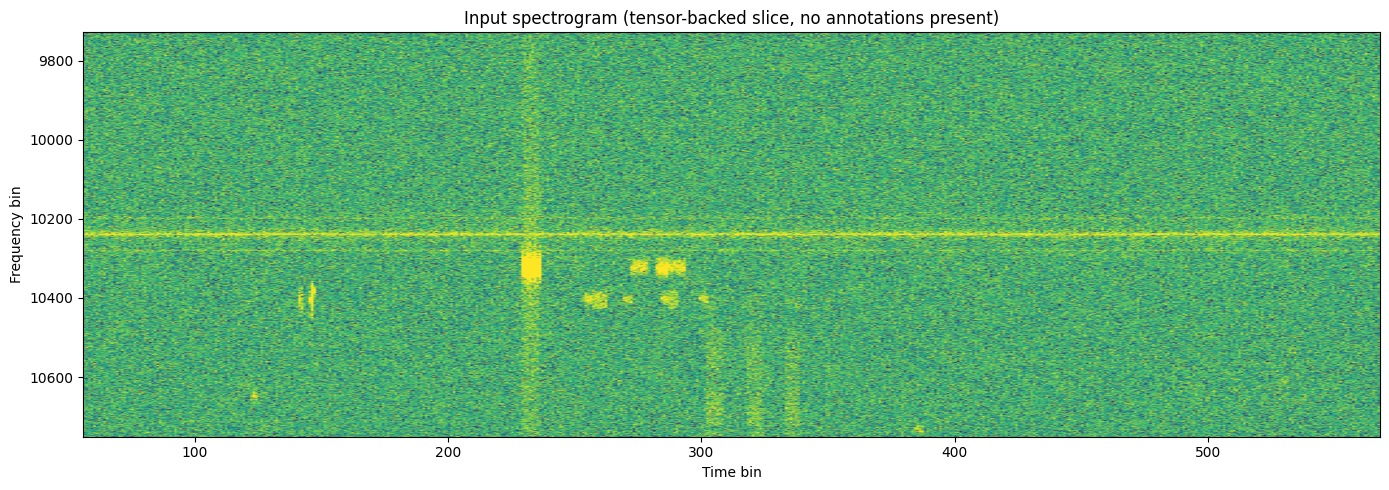

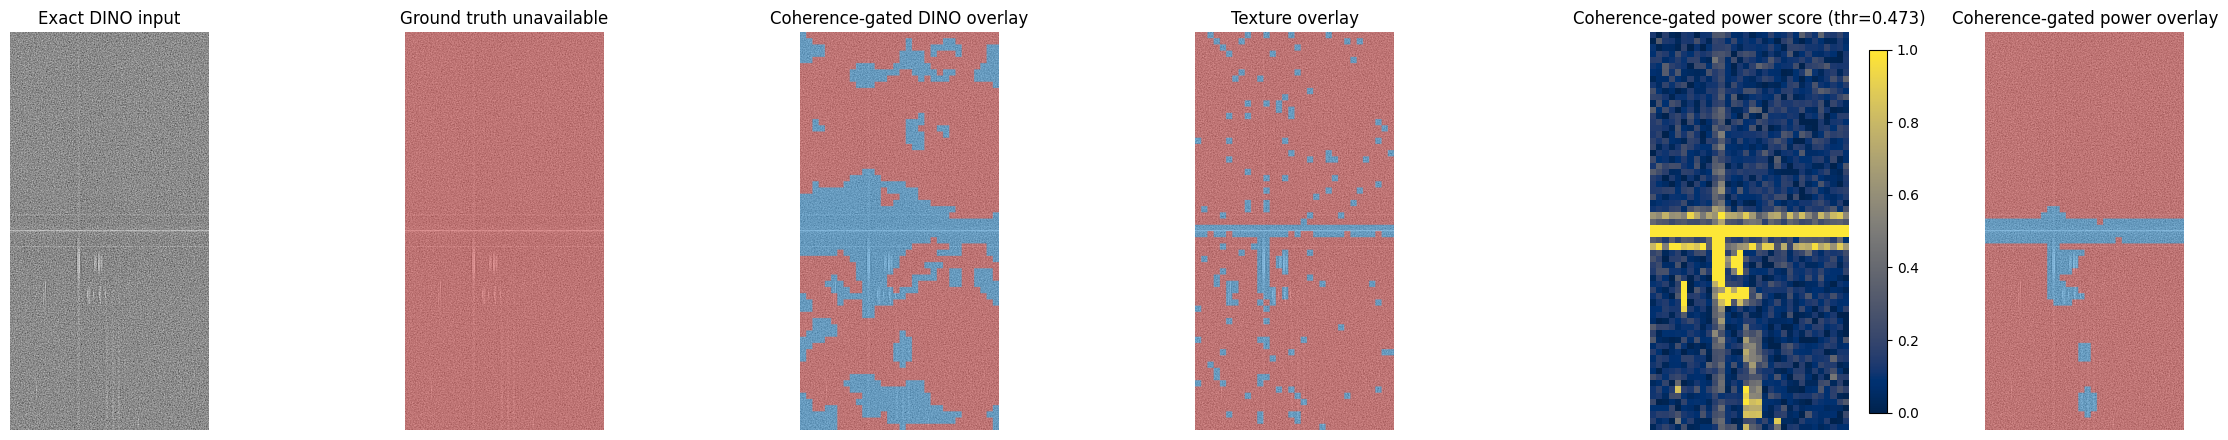

Source: /tmp/usrp_spectrograms/tensors/spectrogram_tensor_ch0_f5_1776039339288_625x20480.npy
Tensor full shape (freq x time): (20480, 625)
Tensor slice rows: (9728, 10752)
Tensor slice cols: (56, 568)
Equivalent preview shape: (1024, 512)
Patch grid: 64 x 32
Preview DINO and power branches use coherence-gated score denoising; texture remains ungated.
No annotations present for this source; preview GT metrics skipped.


In [28]:
sigmf_path = Path(SIGMF_META_PATH)
if DATA_SOURCE == 'sigmf' and not sigmf_path.exists():
    candidates = sorted(Path('/home/sat3737/holoscan_demo_workspace').rglob('*.sigmf-meta'))
    if not candidates:
        raise FileNotFoundError('No .sigmf-meta files found in workspace')
    sigmf_path = candidates[0]
    print(f'Using first discovered SigMF file: {sigmf_path}')

if DATA_SOURCE == 'sigmf':
    _, _, _, configured_annotations = read_sigmf_meta(sigmf_path)
    has_configured_annotations = len(configured_annotations) > 0
    if not has_configured_annotations:
        print(f'Configured SigMF has no annotations: {sigmf_path}')
        print('Annotation-dependent preview metrics will be skipped for this file.')
else:
    has_configured_annotations = False

usrp_chunk_s, usrp_shape = infer_usrp_chunk_duration_seconds(USRP_SPECTROGRAM_DIR)
chunk_seconds = DEFAULT_CHUNK_SECONDS
target_time_bins = None
shape_matched_chunk_s = None
if usrp_shape is not None:
    target_time_bins = int(max(usrp_shape))

if DATA_SOURCE == 'sigmf':
    if USE_USRP_SHAPE_MATCH and (target_time_bins is not None):
        _, probe_params = load_sigmf_samples(
            sigmf_path,
            start_s=SAMPLE_OFFSET_S,
            duration_s=0.01,
            capture_index=0,
            channel=0,
        )
        shape_matched_chunk_s = chunk_seconds_for_target_time_bins(
            sample_rate=probe_params['sample_rate'],
            target_time_bins=target_time_bins,
            nperseg=FFT_SIZE,
            noverlap=NOVERLAP,
        )
        if shape_matched_chunk_s is not None:
            chunk_seconds = shape_matched_chunk_s
    elif USE_USRP_CHUNK_DURATION and (usrp_chunk_s is not None):
        chunk_seconds = usrp_chunk_s

    preview_record = load_preview_record(
        source_kind='sigmf',
        sigmf_path=sigmf_path,
        window_start_s=float(SAMPLE_OFFSET_S),
        chunk_seconds=chunk_seconds,
        target_freq_bins=FFT_SIZE,
        target_time_bins=target_time_bins,
    )
else:
    target_time_bins = int(TENSOR_TARGET_TIME_BINS or target_time_bins or 512)
    target_freq_bins = int(TENSOR_TARGET_FREQ_BINS or FFT_SIZE)
    preview_record = load_preview_record(
        source_kind=DATA_SOURCE,
        target_freq_bins=target_freq_bins,
        target_time_bins=target_time_bins,
    )
    chunk_seconds = float(preview_record['window_duration'])

window_start_s = float(preview_record['window_start_s'])
ann_overlaps = list(preview_record['annotations'])
has_annotations = len(ann_overlaps) > 0

f = np.asarray(preview_record['freq_axis'], dtype=np.float32)
t = np.asarray(preview_record['time_axis'], dtype=np.float32)
sxx_db = np.asarray(preview_record['sxx_db'], dtype=np.float32)
center_frequency = preview_record['center_frequency']
spec_img, _, _ = spectrogram_to_rgb(sxx_db)

dino_vmin, dino_vmax = robust_fixed_db_window(sxx_db)
raw_dino_preview = dino_grouping_from_spectrogram(
    sxx_db,
    db_min=dino_vmin,
    db_max=dino_vmax,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    use_seed=True,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=4,
    random_state=42,
    input_variant='signal_agnostic_gray_preview',
)
dino_preview = apply_coherence_gate_to_dino_result(
    raw_dino_preview,
    sxx_db,
    gate_floor=0.25,
    smooth_iters=1,
    min_component_size=3,
)

gh, gw = dino_preview['shape']
freq_axis_for_gt = f if center_frequency is None else (f - float(center_frequency))
if has_annotations:
    gt_patch, gt_px = sigmf_annotation_patch_mask(
        ann_overlaps,
        time_axis_s=t,
        freq_axis_hz=freq_axis_for_gt,
        patch_h=gh,
        patch_w=gw,
        min_coverage=0.10,
    )
else:
    gt_patch = np.zeros((gh, gw), dtype=np.uint8)
    gt_px = np.zeros_like(sxx_db, dtype=np.uint8)

texture_mask, texture_score, texture_thr = nonlocal_texture_recurrence_mask(
    spec_img,
    patch_h=gh,
    patch_w=gw,
    patch_size=DINO_PATCH_SIZE,
    k=6,
    q=0.90,
)
raw_power_score = power_prior_patch_map(sxx_db, gh, gw)
raw_power_mask, raw_power_thr = threshold_patch_score(raw_power_score, q=0.90)
power_preview = apply_coherence_gate_to_power_score(
    raw_power_score,
    raw_power_mask,
    dino_preview['coherence_gate_patch'],
    gate_floor=DINO_COHERENCE_GATE_FLOOR,
    smooth_iters=1,
    min_component_size=3,
)
power_score = power_preview['score']
power_mask = power_preview['mask']
power_thr = power_preview['threshold']

if has_annotations:
    preview_df = pd.DataFrame([
        {'method': 'coherence_dino', **binary_mask_metrics(dino_preview['mask'], gt_patch)},
        {'method': 'texture', **binary_mask_metrics(texture_mask, gt_patch)},
        {'method': 'coherence_power', **binary_mask_metrics(power_mask, gt_patch)},
    ]).set_index('method')
else:
    preview_df = None

freq_min_hz = float(np.min(freq_axis_for_gt))
freq_max_hz = float(np.max(freq_axis_for_gt))
if preview_record['axis_units'] == 'sigmf':
    time_min = float(t[0]) if len(t) > 0 else 0.0
    time_max = float(t[-1]) if len(t) > 0 else float(chunk_seconds)
    x_label = 'Time (s)'
    y_label = 'Relative Frequency (Hz)' if center_frequency is not None else 'Frequency (Hz)'
    preview_title = 'Input spectrogram with SigMF annotation overlays' if has_annotations else 'Input spectrogram (SigMF, no annotations present)'
else:
    time_min = float(t[0]) if len(t) > 0 else 0.0
    time_max = float(t[-1] + 1.0) if len(t) > 0 else float(sxx_db.shape[1])
    x_label = 'Time bin'
    y_label = 'Frequency bin'
    preview_title = 'Input spectrogram (tensor-backed slice, no annotations present)'

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(
    spec_img,
    aspect='auto',
    origin='lower',
    extent=[time_min, time_max, freq_min_hz, freq_max_hz],
)
ax.set_ylim(freq_max_hz, freq_min_hz)
ax.set_title(preview_title)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
if ann_overlaps:
    draw_sigmf_annotation_overlays(
        ax,
        ann_overlaps,
        time_max_s=time_max,
        freq_min_hz=freq_min_hz,
        freq_max_hz=freq_max_hz,
    )
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 6, figsize=(24, 4.5))
ax[0].imshow(dino_preview['input_img'])
ax[0].set_title('Exact DINO input')
ax[1].imshow(_overlay_from_mask(dino_preview['input_img'], gt_patch))
ax[1].set_title('Ground truth overlay' if has_annotations else 'Ground truth unavailable')
ax[2].imshow(_overlay_from_mask(dino_preview['input_img'], dino_preview['mask']))
ax[2].set_title('Coherence-gated DINO overlay')
ax[3].imshow(_overlay_from_mask(dino_preview['input_img'], texture_mask))
ax[3].set_title('Texture overlay')
im4 = ax[4].imshow(power_score, cmap='cividis')
ax[4].set_title(f'Coherence-gated power score (thr={power_thr:.3f})')
plt.colorbar(im4, ax=ax[4], fraction=0.046)
ax[5].imshow(_overlay_from_mask(dino_preview['input_img'], power_mask))
ax[5].set_title('Coherence-gated power overlay')
for axes in ax:
    axes.axis('off')
plt.tight_layout()
plt.show()

print(f'Source: {preview_record["source_path"]}')
if preview_record['axis_units'] == 'sigmf':
    print(f'Preview start: {window_start_s:.6f} s')
    print(f'Using chunk duration: {chunk_seconds:.6f} s')
else:
    print(f'Tensor full shape (freq x time): {preview_record["raw_shape"]}')
    print(f'Tensor slice rows: {preview_record["slice_rows"]}')
    print(f'Tensor slice cols: {preview_record["slice_cols"]}')
    print(f'Equivalent preview shape: {tuple(int(v) for v in sxx_db.shape)}')
print(f'Patch grid: {gh} x {gw}')
print('Preview DINO and power branches use coherence-gated score denoising; texture remains ungated.')
if preview_df is not None:
    display(preview_df[['iou', 'f1', 'precision', 'recall', 'gt_foreground_fraction']])
else:
    print('No annotations present for this source; preview GT metrics skipped.')


In [36]:
if has_annotations:
    freq_axis_for_gt = f if center_frequency is None else (f - float(center_frequency))
    gt_patch, gt_px = sigmf_annotation_patch_mask(
        ann_overlaps,
        time_axis_s=t,
        freq_axis_hz=freq_axis_for_gt,
        patch_h=gh,
        patch_w=gw,
        min_coverage=0.10,
    )
    preview_df = pd.DataFrame([
        {'method': 'dino', **binary_mask_metrics(dino_preview['mask'], gt_patch)},
        {'method': 'texture', **binary_mask_metrics(texture_mask, gt_patch)},
        {'method': 'power', **binary_mask_metrics(power_mask, gt_patch)},
    ]).set_index('method')
    print('Updated preview GT metrics using relative frequency axis for patch projection.')
    display(preview_df[['iou', 'f1', 'precision', 'recall', 'gt_foreground_fraction']])
else:
    gt_patch = np.zeros((gh, gw), dtype=np.uint8)
    gt_px = np.zeros_like(sxx_db, dtype=np.uint8)
    preview_df = None
    print('No annotations present for this file; preview GT metrics remain skipped.')

No annotations present for this file; preview GT metrics remain skipped.


In [30]:
SNR_SWEEP_DB = list(range(30, -41, -10))
TEXTURE_Q = 0.90
TEXTURE_K = 6
POWER_Q = 0.90

DINO_GROUP_K = 8
DINO_GROUP_SPATIAL_WEIGHT = 0.35
DINO_GROUP_SCORE_Q = 0.60
DINO_COHERENCE_GATE_FLOOR = 0.25

NOISE_SEED = 42

if DATA_SOURCE != 'sigmf':
    sweep_meta_path = None
    sweep_start_s = None
    sweep_fs = None
    sweep_center_frequency = None
    gt_ann_sweep = []
    sweep_has_annotations = False
    f_snr = np.array([], dtype=np.float32)
    t_snr = np.array([], dtype=np.float32)
    snr_results = []
    snr_eval_df = pd.DataFrame()
    print('SNR sweep skipped: DATA_SOURCE is not "sigmf". Switch DATA_SOURCE to "sigmf" and rerun cells 4 through 15 for IQ-domain sweep evaluation.')
else:
    sweep_meta_path = sigmf_path
    sweep_start_s = float(SAMPLE_OFFSET_S)
    iq_clean, sweep_fs, sweep_center_frequency = load_chunk_for_file(
        meta_path=sweep_meta_path,
        start_s=sweep_start_s,
        duration_s=chunk_seconds,
    )

    _, _, sxx_orig_db = generate_spectrogram(
        iq_clean,
        fs=sweep_fs,
        nperseg=FFT_SIZE,
        noverlap=NOVERLAP,
        center_frequency=sweep_center_frequency,
    )
    orig_noise_floor_db = estimate_original_noise_floor_db(sxx_orig_db)
    p_signal_est, p_noise_orig_est, p_total_est, orig_snr_db = estimate_original_snr_from_iq(
        iq_clean,
        orig_noise_floor_db,
    )

    dino_vmin, dino_vmax = robust_fixed_db_window(sxx_orig_db)
    gt_ann_sweep = get_overlapping_sigmf_annotations(
        sweep_meta_path,
        window_start_s=sweep_start_s,
        window_duration_s=chunk_seconds,
        capture_index=0,
    )
    sweep_has_annotations = len(gt_ann_sweep) > 0

    rng = np.random.default_rng(NOISE_SEED)
    gt_patch_cache = {}
    snr_results = []

    for snr_db in SNR_SWEEP_DB:
        noisy_iq, p_noise_added, p_noise_total_est, actual_snr_db = add_awgn_for_target_snr(
            iq_clean=iq_clean,
            p_signal_est=p_signal_est,
            p_noise_orig_est=p_noise_orig_est,
            target_snr_db=snr_db,
            rng=rng,
        )

        f_snr, t_snr, sxx_snr_db = generate_spectrogram(
            noisy_iq,
            fs=sweep_fs,
            nperseg=FFT_SIZE,
            noverlap=NOVERLAP,
            center_frequency=sweep_center_frequency,
        )

        spec_model_img, _, _ = spectrogram_to_rgb(sxx_snr_db)

        dino_base_start = time.perf_counter()
        raw_dino_group = dino_grouping_from_spectrogram(
            sxx_snr_db,
            db_min=dino_vmin,
            db_max=dino_vmax,
            feature_knn=DINO_GROUP_K,
            spatial_weight=DINO_GROUP_SPATIAL_WEIGHT,
            score_q=DINO_GROUP_SCORE_Q,
            use_seed=True,
            smooth_iters=2,
            min_component_size=6,
            n_clusters=4,
            random_state=42,
            input_variant='signal_agnostic_gray_sweep',
        )
        dino_base_runtime_ms = 1000.0 * (time.perf_counter() - dino_base_start)

        dino_coherence_start = time.perf_counter()
        dino_group = apply_coherence_gate_to_dino_result(
            raw_dino_group,
            sxx_snr_db,
            gate_floor=DINO_COHERENCE_GATE_FLOOR,
            smooth_iters=1,
            min_component_size=3,
        )
        dino_coherence_runtime_ms = 1000.0 * (time.perf_counter() - dino_coherence_start)
        dino_total_runtime_ms = dino_base_runtime_ms + dino_coherence_runtime_ms

        gh_snr, gw_snr = dino_group['shape']
        shape = (gh_snr, gw_snr)
        if sweep_has_annotations:
            if shape not in gt_patch_cache:
                freq_axis_for_gt = f_snr if sweep_center_frequency is None else (f_snr - float(sweep_center_frequency))
                gt_patch_cache[shape], _ = sigmf_annotation_patch_mask(
                    gt_ann_sweep,
                    time_axis_s=t_snr,
                    freq_axis_hz=freq_axis_for_gt,
                    patch_h=gh_snr,
                    patch_w=gw_snr,
                    min_coverage=0.10,
                )
            gt_patch = gt_patch_cache[shape].astype(np.uint8)
        else:
            gt_patch = np.zeros(shape, dtype=np.uint8)

        texture_mask, texture_score, texture_thr = nonlocal_texture_recurrence_mask(
            spec_model_img,
            patch_h=gh_snr,
            patch_w=gw_snr,
            patch_size=DINO_PATCH_SIZE,
            k=TEXTURE_K,
            q=TEXTURE_Q,
        )

        power_raw_score = power_prior_patch_map(sxx_snr_db, gh_snr, gw_snr)
        power_raw_mask, power_raw_thr = threshold_patch_score(power_raw_score, q=POWER_Q)
        power_coherence_start = time.perf_counter()
        power_branch = apply_coherence_gate_to_power_score(
            power_raw_score,
            power_raw_mask,
            dino_group['coherence_gate_patch'],
            gate_floor=DINO_COHERENCE_GATE_FLOOR,
            smooth_iters=1,
            min_component_size=3,
        )
        power_coherence_runtime_ms = 1000.0 * (time.perf_counter() - power_coherence_start)
        hybrid_branch_runtime_ms = dino_total_runtime_ms + power_coherence_runtime_ms

        hybrid = hybrid_fusion_from_components(
            texture_score_patch=texture_score,
            dino_score_patch=dino_group['score'],
            power_score_patch=power_branch['score'],
            snr_db=actual_snr_db,
            q=0.90,
        )
        power_raw_contrib = (hybrid['w_power'] * _normalize_map01_local(power_raw_score, 5.0, 95.0)).astype(np.float32)

        if sweep_has_annotations:
            dino_metrics = binary_mask_metrics(dino_group['mask'], gt_patch)
            texture_metrics = binary_mask_metrics(texture_mask, gt_patch)
            power_metrics = binary_mask_metrics(power_branch['mask'], gt_patch)
            hybrid_metrics = binary_mask_metrics(hybrid['hybrid_mask'], gt_patch)
            gt_metrics = _spatial_metrics(gt_patch)
        else:
            dino_metrics = None
            texture_metrics = None
            power_metrics = None
            hybrid_metrics = None
            gt_metrics = None

        snr_results.append({
            'snr_db': snr_db,
            'actual_snr_db': actual_snr_db,
            'signal_power_est': p_signal_est,
            'noise_power_orig_est': p_noise_orig_est,
            'noise_power_added': p_noise_added,
            'noise_power_total_est': p_noise_total_est,
            'orig_snr_db': orig_snr_db,
            'orig_noise_floor_db': orig_noise_floor_db,
            'shape': shape,
            'spectrogram_db': sxx_snr_db,
            'spec_img': dino_group['input_img'],
            'gt_mask': gt_patch,
            'has_annotations': sweep_has_annotations,
            'dino_mask': dino_group['mask'],
            'dino_score_map': dino_group['score'],
            'dino_threshold': dino_group['threshold'],
            'dino_input_patch_map': dino_group['input_patch'],
            'dino_input_row_corr': dino_group['input_row_corr'],
            'dino_input_col_corr': dino_group['input_col_corr'],
            'dino_positional_trend_ratio': dino_group['positional_trend_ratio'],
            'dino_removed_position_components': dino_group.get('removed_position_components', 0),
            'dino_raw_mask': dino_group['raw_mask'],
            'dino_raw_score_map': dino_group['raw_score'],
            'dino_raw_threshold': dino_group['raw_threshold'],
            'dino_coherence_gate_map': dino_group['coherence_gate_patch'],
            'dino_base_runtime_ms': float(dino_base_runtime_ms),
            'dino_coherence_runtime_ms': float(dino_coherence_runtime_ms),
            'dino_total_runtime_ms': float(dino_total_runtime_ms),
            'texture_mask': texture_mask,
            'texture_score_map': texture_score,
            'texture_threshold': texture_thr,
            'power_raw_mask': power_raw_mask,
            'power_raw_score_map': power_raw_score,
            'power_raw_threshold': power_raw_thr,
            'power_raw_contrib_map': power_raw_contrib,
            'power_mask': power_branch['mask'],
            'power_score_map': power_branch['score'],
            'power_threshold': power_branch['threshold'],
            'power_target_foreground_fraction': power_branch['target_foreground_fraction'],
            'power_coherence_gate_map': power_branch['coherence_gate_patch'],
            'power_coherence_runtime_ms': float(power_coherence_runtime_ms),
            'hybrid_branch_runtime_ms': float(hybrid_branch_runtime_ms),
            'hybrid_mask': hybrid['hybrid_mask'],
            'hybrid_score_map': hybrid['hybrid_score'],
            'hybrid_threshold': hybrid['hybrid_threshold'],
            'hybrid_w_texture': hybrid['w_texture'],
            'hybrid_w_dino': hybrid['w_dino'],
            'hybrid_w_power': hybrid['w_power'],
            'texture_contrib_map': hybrid['texture_contrib'],
            'dino_contrib_map': hybrid['dino_contrib'],
            'power_contrib_map': hybrid['power_contrib'],
            'dino_power_contrib_map': (hybrid['dino_contrib'] + hybrid['power_contrib']).astype(np.float32),
            'gt_metrics': gt_metrics,
            'dino_metrics': dino_metrics,
            'texture_metrics': texture_metrics,
            'power_metrics': power_metrics,
            'hybrid_metrics': hybrid_metrics,
        })

    snr_eval_rows = []
    for r in snr_results:
        snr_eval_rows.append({
            'snr_db': r['snr_db'],
            'actual_snr_db': r['actual_snr_db'],
            'gt_foreground_fraction': np.nan if r['gt_metrics'] is None else r['gt_metrics']['foreground_fraction'],
            'dino_iou': np.nan if r['dino_metrics'] is None else r['dino_metrics']['iou'],
            'dino_f1': np.nan if r['dino_metrics'] is None else r['dino_metrics']['f1'],
            'texture_iou': np.nan if r['texture_metrics'] is None else r['texture_metrics']['iou'],
            'texture_f1': np.nan if r['texture_metrics'] is None else r['texture_metrics']['f1'],
            'power_iou': np.nan if r['power_metrics'] is None else r['power_metrics']['iou'],
            'power_f1': np.nan if r['power_metrics'] is None else r['power_metrics']['f1'],
            'hybrid_iou': np.nan if r['hybrid_metrics'] is None else r['hybrid_metrics']['iou'],
            'hybrid_f1': np.nan if r['hybrid_metrics'] is None else r['hybrid_metrics']['f1'],
            'dino_foreground_fraction': float(r['dino_mask'].mean()),
            'texture_foreground_fraction': float(r['texture_mask'].mean()),
            'power_foreground_fraction': float(r['power_mask'].mean()),
            'hybrid_foreground_fraction': float(r['hybrid_mask'].mean()),
            'dino_input_row_corr': r['dino_input_row_corr'],
            'dino_input_col_corr': r['dino_input_col_corr'],
            'dino_positional_trend_ratio': r['dino_positional_trend_ratio'],
            'dino_removed_position_components': r['dino_removed_position_components'],
            'dino_base_runtime_ms': r['dino_base_runtime_ms'],
            'dino_coherence_runtime_ms': r['dino_coherence_runtime_ms'],
            'dino_total_runtime_ms': r['dino_total_runtime_ms'],
            'power_coherence_runtime_ms': r['power_coherence_runtime_ms'],
            'hybrid_branch_runtime_ms': r['hybrid_branch_runtime_ms'],
        })

    snr_eval_df = pd.DataFrame(snr_eval_rows).sort_values('snr_db', ascending=False)
    if sweep_has_annotations:
        print('SNR sweep evaluation vs SigMF annotation boxes using coherence-gated DINO, coherence-gated power, and fixed 50/25/25 hybrid fusion.')
    else:
        print('Configured SigMF has no overlapping annotations; SNR sweep GT metrics skipped.')
    display(snr_eval_df)

SNR sweep skipped: DATA_SOURCE is not "sigmf". Switch DATA_SOURCE to "sigmf" and rerun cells 4 through 15 for IQ-domain sweep evaluation.


In [31]:
if DATA_SOURCE != 'sigmf':
    print('Cell 16 skipped: SNR evaluation recompute is only available in SigMF mode.')
else:
    freq_axis_sweep = f_snr if sweep_center_frequency is None else (f_snr - float(sweep_center_frequency))
    gt_patch_cache = {}
    snr_eval_rows = []
    for r in snr_results:
        shape = tuple(r['shape'])
        if sweep_has_annotations:
            if shape not in gt_patch_cache:
                gt_patch_cache[shape], _ = sigmf_annotation_patch_mask(
                    gt_ann_sweep,
                    time_axis_s=t_snr,
                    freq_axis_hz=freq_axis_sweep,
                    patch_h=shape[0],
                    patch_w=shape[1],
                    min_coverage=0.10,
                )
            gt_patch = gt_patch_cache[shape].astype(np.uint8)
            r['gt_mask'] = gt_patch
            r['dino_metrics'] = binary_mask_metrics(r['dino_mask'], gt_patch)
            r['texture_metrics'] = binary_mask_metrics(r['texture_mask'], gt_patch)
            r['power_metrics'] = binary_mask_metrics(r['power_mask'], gt_patch)
            r['hybrid_metrics'] = binary_mask_metrics(r['hybrid_mask'], gt_patch)
            r['gt_metrics'] = _spatial_metrics(gt_patch)
        else:
            gt_patch = np.zeros(shape, dtype=np.uint8)
            r['gt_mask'] = gt_patch
            r['dino_metrics'] = None
            r['texture_metrics'] = None
            r['power_metrics'] = None
            r['hybrid_metrics'] = None
            r['gt_metrics'] = None

        snr_eval_rows.append({
            'snr_db': r['snr_db'],
            'actual_snr_db': r['actual_snr_db'],
            'gt_foreground_fraction': np.nan if r['gt_metrics'] is None else r['gt_metrics']['foreground_fraction'],
            'dino_iou': np.nan if r['dino_metrics'] is None else r['dino_metrics']['iou'],
            'dino_f1': np.nan if r['dino_metrics'] is None else r['dino_metrics']['f1'],
            'texture_iou': np.nan if r['texture_metrics'] is None else r['texture_metrics']['iou'],
            'texture_f1': np.nan if r['texture_metrics'] is None else r['texture_metrics']['f1'],
            'power_iou': np.nan if r['power_metrics'] is None else r['power_metrics']['iou'],
            'power_f1': np.nan if r['power_metrics'] is None else r['power_metrics']['f1'],
            'hybrid_iou': np.nan if r['hybrid_metrics'] is None else r['hybrid_metrics']['iou'],
            'hybrid_f1': np.nan if r['hybrid_metrics'] is None else r['hybrid_metrics']['f1'],
            'dino_foreground_fraction': float(r['dino_mask'].mean()),
            'texture_foreground_fraction': float(r['texture_mask'].mean()),
            'power_foreground_fraction': float(r['power_mask'].mean()),
            'hybrid_foreground_fraction': float(r['hybrid_mask'].mean()),
            'dino_input_row_corr': r['dino_input_row_corr'],
            'dino_input_col_corr': r['dino_input_col_corr'],
            'dino_positional_trend_ratio': r['dino_positional_trend_ratio'],
            'dino_removed_position_components': r['dino_removed_position_components'],
            'dino_base_runtime_ms': r['dino_base_runtime_ms'],
            'dino_coherence_runtime_ms': r['dino_coherence_runtime_ms'],
            'dino_total_runtime_ms': r['dino_total_runtime_ms'],
            'power_coherence_runtime_ms': r['power_coherence_runtime_ms'],
            'hybrid_branch_runtime_ms': r['hybrid_branch_runtime_ms'],
        })

    snr_eval_df = pd.DataFrame(snr_eval_rows).sort_values('snr_db', ascending=False)
    if sweep_has_annotations:
        print('Recomputed SNR sweep evaluation using relative frequency axis for GT patch projection with coherence-gated DINO, coherence-gated power, and fixed 50/25/25 hybrid fusion.')
    else:
        print('No annotations present; GT-based SNR sweep metrics remain skipped.')
    display(snr_eval_df)

Cell 16 skipped: SNR evaluation recompute is only available in SigMF mode.


In [32]:
if DATA_SOURCE != 'sigmf':
    print('Cell 17 skipped: SNR sweep plots are only available in SigMF mode.')
else:
    fig, ax = plt.subplots(1, 4, figsize=(22, 4.5))
    if sweep_has_annotations:
        for method in ['dino', 'texture', 'power', 'hybrid']:
            ax[0].plot(snr_eval_df['snr_db'], snr_eval_df[f'{method}_iou'], marker='o', label=method)
            ax[1].plot(snr_eval_df['snr_db'], snr_eval_df[f'{method}_f1'], marker='o', label=method)

        ax[0].set_title('IoU vs SNR')
        ax[0].set_xlabel('SNR (dB)')
        ax[0].set_ylabel('IoU')
        ax[0].set_ylim(0.0, 1.0)
        ax[0].grid(True, alpha=0.3)
        ax[0].legend()

        ax[1].set_title('F1 vs SNR')
        ax[1].set_xlabel('SNR (dB)')
        ax[1].set_ylabel('F1')
        ax[1].set_ylim(0.0, 1.0)
        ax[1].grid(True, alpha=0.3)
    else:
        ax[0].axis('off')
        ax[0].text(0.5, 0.5, 'No annotations\nIoU unavailable', ha='center', va='center', fontsize=12)
        ax[1].axis('off')
        ax[1].text(0.5, 0.5, 'No annotations\nF1 unavailable', ha='center', va='center', fontsize=12)

    for method in ['dino', 'texture', 'power', 'hybrid']:
        ax[2].plot(snr_eval_df['snr_db'], snr_eval_df[f'{method}_foreground_fraction'], marker='o', label=method)

    ax[2].set_title('Foreground Fraction vs SNR')
    ax[2].set_xlabel('SNR (dB)')
    ax[2].set_ylabel('Foreground fraction')
    ax[2].set_ylim(0.0, 1.0)
    ax[2].grid(True, alpha=0.3)
    ax[2].legend()

    ax[3].plot(snr_eval_df['snr_db'], snr_eval_df['dino_base_runtime_ms'], marker='o', label='base DINO')
    ax[3].plot(snr_eval_df['snr_db'], snr_eval_df['dino_coherence_runtime_ms'], marker='o', label='DINO coherence build')
    ax[3].plot(snr_eval_df['snr_db'], snr_eval_df['power_coherence_runtime_ms'], marker='o', label='power gate apply')
    ax[3].plot(snr_eval_df['snr_db'], snr_eval_df['hybrid_branch_runtime_ms'], marker='o', label='gated DINO+power prep')
    ax[3].set_title('Branch Runtime vs SNR')
    ax[3].set_xlabel('SNR (dB)')
    ax[3].set_ylabel('Runtime (ms)')
    ax[3].grid(True, alpha=0.3)
    ax[3].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

Cell 17 skipped: SNR sweep plots are only available in SigMF mode.


In [33]:
if DATA_SOURCE != 'sigmf':
    print('Cell 18 skipped: contribution review panels are only available in SigMF mode.')
else:
    n = len(snr_results)
    fig, axes = plt.subplots(n, 6, figsize=(24, 4.0 * n), constrained_layout=True)
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, r in enumerate(snr_results):
        ax = axes[row_idx]

        dino_contrib = np.asarray(r['dino_contrib_map'], dtype=np.float32)
        texture_contrib = np.asarray(r['texture_contrib_map'], dtype=np.float32)
        power_contrib = np.asarray(r['power_contrib_map'], dtype=np.float32)

        dino_display = _normalize_map01_local(dino_contrib, 5.0, 95.0).astype(np.float32)
        texture_display = _normalize_map01_local(texture_contrib, 5.0, 95.0).astype(np.float32)
        power_display = _normalize_map01_local(power_contrib, 5.0, 95.0).astype(np.float32)

        ax[0].imshow(r['spec_img'])
        ax[0].set_title(f"SNR {r['snr_db']} dB\nExact DINO input")

        ax[1].imshow(_overlay_from_mask(r['spec_img'], r['gt_mask']))
        ax[1].set_title('Ground truth' if r.get('has_annotations', False) else 'Ground truth unavailable')

        ax[2].imshow(dino_display, cmap='magma', vmin=0.0, vmax=1.0, interpolation='nearest')
        ax[2].set_title(
            f"Coherence-gated DINO contribution\nplot-norm, w={r['hybrid_w_dino']:.2f}, {r['dino_total_runtime_ms']:.0f} ms"
        )

        ax[3].imshow(texture_display, cmap='magma', vmin=0.0, vmax=1.0, interpolation='nearest')
        ax[3].set_title(f"Texture contribution\nplot-norm, w={r['hybrid_w_texture']:.2f}")

        ax[4].imshow(power_display, cmap='magma', vmin=0.0, vmax=1.0, interpolation='nearest')
        ax[4].set_title(
            f"Coherence-gated power contribution\nplot-norm, w={r['hybrid_w_power']:.2f}, {r['power_coherence_runtime_ms']:.1f} ms"
        )

        ax[5].imshow(_overlay_from_mask(r['spec_img'], r['hybrid_mask']))
        if r['hybrid_metrics'] is not None:
            ax[5].set_title(f"Hybrid combined mask\nF1={r['hybrid_metrics']['f1']:.2f}")
        else:
            ax[5].set_title('Hybrid combined mask')

        for cur_ax in ax:
            cur_ax.axis('off')

    fig.colorbar(
        plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=0.0, vmax=1.0)),
        ax=axes[:, 2:5].ravel().tolist(),
        fraction=0.025,
        pad=0.01,
        label='Per-panel normalized raw contribution',
    )
    plt.show()

Cell 18 skipped: contribution review panels are only available in SigMF mode.


Fixed pipeline comparison: texture now drops quickly from full pass-through to 25%, then toward 10%, and is added into D+P headroom instead of suppressing the base agreement.


,snr_db,actual_snr_db,texture_reliability,structure_speckle_score,structure_clean_score,texture_passthrough,score_pass_fg,structure_pass_fg,power_weighted_structure_pass_fg,structure_rescue_gain_fg,strong_candidate_fg,mid_candidate_fg,raw_structure_candidate_fg,power_rescue_fg,low_candidate_fg,base_fg,final_fg


,snr_db,actual_snr_db,has_annotations,texture_reliability,structure_clean_score,texture_passthrough,strong_thr,mid_thr,low_thr,structure_thr,power_rescue_floor,power_rescue_gain,base_fg,multilevel_fg,base_f1,multilevel_f1,base_iou,multilevel_iou,base_gap_recall,multilevel_gap_recall


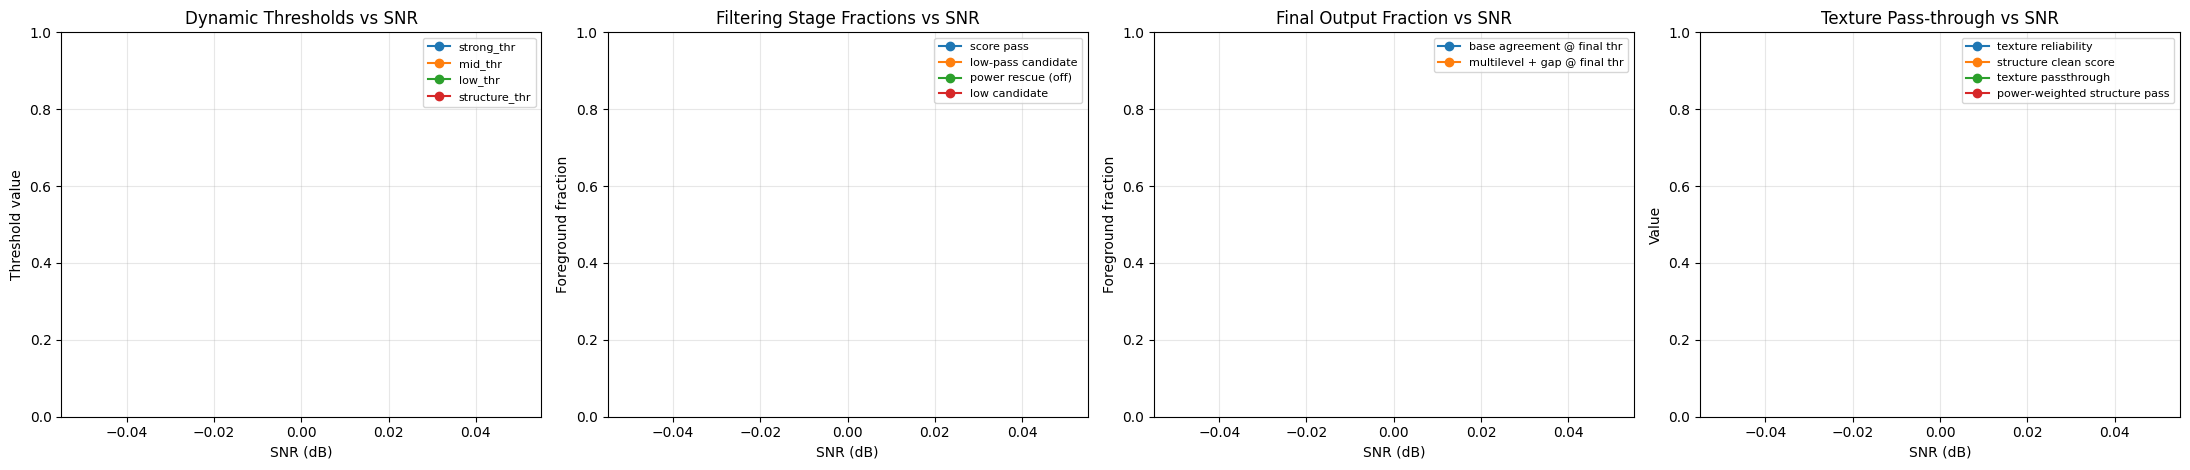

No pipeline visuals available for the selected PIPELINE_VISUAL_SNRS.
No overlay visuals available for the selected PIPELINE_VISUAL_SNRS.


In [34]:
PIPELINE_VISUAL_SNRS = [30, 20, 10, 0, -10, -20, -30]
PIPELINE_FINAL_THRESHOLD = 0.25
PIPELINE_FINAL_THRESHOLD_NO_SPECKLE = 0.1
PIPELINE_GAP_FLOOR = 0.10
PIPELINE_COMPONENT_MIN_SIZE = 5
PIPELINE_COMPONENT_MIN_SIZE_NO_SPECKLE = 2
PIPELINE_POWER_RESCUE_FLOOR = 0.10
PIPELINE_POWER_RESCUE_GAIN = 5.000

from scipy import ndimage as ndi


def _pipeline_safe_quantile(arr, q):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.size == 0:
        return 0.0
    return float(np.quantile(arr, q))


def _pipeline_component_speckle_score(mask, min_size=6):
    mask = np.asarray(mask, dtype=np.uint8)
    total = int(mask.sum())
    if total == 0:
        return 0.0
    labels, n_labels = ndi.label(mask)
    if n_labels == 0:
        return 0.0
    counts = np.bincount(labels.ravel())
    if counts.size == 0:
        return 0.0
    counts[0] = 0
    small_pixels = int(counts[(counts > 0) & (counts < int(min_size))].sum())
    return float(np.clip(1.0 - (small_pixels / max(total, 1)), 0.0, 1.0))


def _pipeline_texture_reliability(texture_map, agreement_map):
    eps = 1e-6
    texture_map = np.asarray(texture_map, dtype=np.float32)
    agreement_map = np.asarray(agreement_map, dtype=np.float32)

    q20 = _pipeline_safe_quantile(texture_map, 0.20)
    q60 = _pipeline_safe_quantile(texture_map, 0.60)
    q85 = _pipeline_safe_quantile(texture_map, 0.85)
    q95 = _pipeline_safe_quantile(texture_map, 0.95)

    peakiness = float(np.clip((q95 - q60) / (q95 - q20 + eps), 0.0, 1.0))
    texture_top_mask = texture_map >= q85
    speckle_score = _pipeline_component_speckle_score(texture_top_mask, min_size=6)

    if texture_top_mask.any():
        coherence_support = float(np.mean(agreement_map[texture_top_mask]))
    else:
        coherence_support = 0.0

    agreement_top_mask = agreement_map >= _pipeline_safe_quantile(agreement_map, 0.85)
    union = texture_top_mask | agreement_top_mask
    if union.any():
        overlap = float(np.logical_and(texture_top_mask, agreement_top_mask).sum()) / float(union.sum())
    else:
        overlap = 0.0

    return float(np.clip(
        0.35 * peakiness + 0.25 * speckle_score + 0.20 * coherence_support + 0.20 * overlap,
        0.0,
        1.0,
    ))


def _pipeline_structure_texture_passthrough(structure_map, reliability):
    structure_map = np.asarray(structure_map, dtype=np.float32)
    q70 = _pipeline_safe_quantile(structure_map, 0.70)
    q90 = _pipeline_safe_quantile(structure_map, 0.90)
    structure_top_mask = structure_map >= q70
    structure_peak_mask = structure_map >= q90

    min_size = max(4, int(round(4 + 4 * reliability)))
    structure_speckle = _pipeline_component_speckle_score(structure_top_mask, min_size=min_size)
    if structure_peak_mask.any():
        structure_peak = float(np.mean(structure_map[structure_peak_mask]))
    else:
        structure_peak = 0.0

    structure_clean_score = float(np.clip(0.70 * structure_speckle + 0.30 * structure_peak, 0.0, 1.0))
    # Texture weight schedule driven by speckle:
    #   No speckle (speckle_score near 1.0)  -> 1.00 (100 % additive)
    #   Speckle just detected (onset ~0.85)  -> 0.25
    #   Strong speckle (score <= 0.20)       -> 0.05
    _speckle_clean_thr  = 0.96
    _speckle_strong_thr = 0.50
    if structure_speckle >= _speckle_clean_thr:
        clean_ramp = float(np.clip((structure_speckle - _speckle_clean_thr) / (1.0 - _speckle_clean_thr), 0.0, 1.0))
        texture_passthrough = 0.25 + 0.75 * clean_ramp
    elif structure_speckle >= _speckle_strong_thr:
        speckle_ramp = float(np.clip((structure_speckle - _speckle_strong_thr) / (_speckle_clean_thr - _speckle_strong_thr), 0.0, 1.0))
        texture_passthrough = 0.05 + 0.20 * speckle_ramp
    else:
        texture_passthrough = 0.05
    return {
        'structure_speckle_score': structure_speckle,
        'structure_peak_score': structure_peak,
        'structure_clean_score': structure_clean_score,
        'texture_passthrough': float(np.clip(texture_passthrough, 0.05, 1.0)),
    }


def _pipeline_gap_recall(pred_mask, gt_mask, texture_mask):
    pred_mask = np.asarray(pred_mask, dtype=bool)
    gt_mask = np.asarray(gt_mask, dtype=bool)
    texture_mask = np.asarray(texture_mask, dtype=bool)
    gap_gt = gt_mask & (~texture_mask)
    total = int(gap_gt.sum())
    if total == 0:
        return np.nan
    pred_fill = pred_mask & (~texture_mask)
    return float((pred_fill & gap_gt).sum()) / float(total)


def _build_multilevel_gap_pipeline(
    score_map,
    structure_map,
    texture_map,
    reliability,
    gap_floor,
    raw_power_map=None,
    power_rescue_floor=PIPELINE_POWER_RESCUE_FLOOR,
    power_rescue_gain=PIPELINE_POWER_RESCUE_GAIN,
):
    score_map = np.asarray(score_map, dtype=np.float32)
    structure_map = np.asarray(structure_map, dtype=np.float32)
    texture_map = np.asarray(texture_map, dtype=np.float32)
    if raw_power_map is None:
        raw_power_map = np.zeros_like(score_map, dtype=np.float32)
    raw_power_map = np.asarray(raw_power_map, dtype=np.float32)

    strong_thr = float(0.44 + 0.12 * reliability)
    mid_thr = float(0.24 + 0.10 * reliability)
    low_thr = float(0.10 + 0.08 * reliability)
    structure_thr = float(0.45 + 0.12 * reliability)
    score_pass_gate = (score_map >= low_thr).astype(np.float32)

    raw_power_local_mean = ndi.uniform_filter(
        _normalize_map01_local(raw_power_map, 5.0, 95.0).astype(np.float32),
        size=3,
        mode='nearest',
    ).astype(np.float32)
    power_rescue_floor = float(np.clip(power_rescue_floor, 0.0, 0.99))
    power_rescue_gain = float(np.clip(power_rescue_gain, 0.0, 2.0))
    power_rescue_term = np.clip(
        (raw_power_local_mean - power_rescue_floor) / max(1.0 - power_rescue_floor, 1e-6),
        0.0,
        1.0,
    ).astype(np.float32)
    structure_rescue_span = float(max(structure_thr - low_thr, 0.05))
    power_weighted_structure = np.clip(
        structure_map + power_rescue_gain * structure_rescue_span * (score_pass_gate * power_rescue_term),
        0.0,
        1.0,
    ).astype(np.float32)

    strong_candidate_mask = (score_map >= strong_thr).astype(np.uint8)
    mid_candidate_mask = (score_map >= mid_thr).astype(np.uint8)
    raw_structure_candidate_mask = score_pass_gate.astype(np.uint8)
    power_rescue_mask = np.zeros_like(raw_structure_candidate_mask, dtype=np.uint8)
    low_candidate_mask = score_pass_gate.astype(np.uint8)

    strong_score = (1.00 * score_map * strong_candidate_mask.astype(np.float32)).astype(np.float32)
    mid_score = (1 * score_map * mid_candidate_mask.astype(np.float32)).astype(np.float32)
    low_candidate_score = (1 * score_map * low_candidate_mask.astype(np.float32)).astype(np.float32)
    stacked_pre_gap = np.maximum.reduce([strong_score, mid_score, low_candidate_score]).astype(np.float32)

    texture_policy = _pipeline_structure_texture_passthrough(structure_map, reliability)
    gap_floor = float(np.clip(gap_floor, 0.0, 1.0))
    texture_weight = float(np.clip(texture_policy['texture_passthrough'], gap_floor, 1.0))
    texture_penalty_strength = float(1.0 - texture_weight)
    gap_weight = np.full_like(texture_map, texture_weight, dtype=np.float32)
    texture_passthrough_score = (texture_weight * texture_map * (1.0 - stacked_pre_gap)).astype(np.float32)
    pre_gap_score = np.clip(stacked_pre_gap + texture_passthrough_score, 0.0, 1.0).astype(np.float32)
    final_map = _normalize_map01_local(pre_gap_score, 5.0, 95.0).astype(np.float32)

    return {
        'strong_thr': strong_thr,
        'mid_thr': mid_thr,
        'low_thr': low_thr,
        'structure_thr': structure_thr,
        'power_rescue_floor': power_rescue_floor,
        'power_rescue_gain': power_rescue_gain,
        'strong_candidate_mask': strong_candidate_mask.astype(np.uint8),
        'mid_candidate_mask': mid_candidate_mask.astype(np.uint8),
        'raw_power_local_mean': raw_power_local_mean,
        'power_rescue_term': power_rescue_term,
        'power_weighted_structure': power_weighted_structure,
        'raw_structure_candidate_mask': raw_structure_candidate_mask.astype(np.uint8),
        'power_rescue_mask': power_rescue_mask.astype(np.uint8),
        'low_candidate_mask': low_candidate_mask.astype(np.uint8),
        'strong_score': strong_score,
        'mid_score': mid_score,
        'low_candidate_score': low_candidate_score,
        'stacked_pre_gap': stacked_pre_gap,
        'texture_passthrough_score': texture_passthrough_score,
        'pre_gap_score': pre_gap_score,
        'structure_speckle_score': float(texture_policy['structure_speckle_score']),
        'structure_peak_score': float(texture_policy['structure_peak_score']),
        'structure_clean_score': float(texture_policy['structure_clean_score']),
        'texture_passthrough': texture_weight,
        'texture_penalty_strength': texture_penalty_strength,
        'gap_weight': gap_weight,
        'final_map': final_map,
    }


pipeline_fixed_rows = []
pipeline_visuals = []
pipeline_overlay_visuals = []
pipeline_stage_rows = []

for result in sorted(snr_results, key=lambda row: row['snr_db'], reverse=True):
    dino_map = _normalize_map01_local(np.asarray(result['dino_score_map'], dtype=np.float32), 5.0, 95.0).astype(np.float32)
    power_map = _normalize_map01_local(np.asarray(result['power_score_map'], dtype=np.float32), 5.0, 95.0).astype(np.float32)
    raw_power_map = np.asarray(result['power_raw_score_map'], dtype=np.float32)
    texture_map = _normalize_map01_local(np.asarray(result['texture_score_map'], dtype=np.float32), 5.0, 95.0).astype(np.float32)
    structure_map = _normalize_map01_local(
        np.asarray(result.get('dino_coherence_gate_map', result['dino_score_map']), dtype=np.float32),
        5.0,
        95.0,
    ).astype(np.float32)

    agreement_map = np.sqrt(np.clip(dino_map * power_map, 0.0, None)).astype(np.float32)
    texture_reliability = _pipeline_texture_reliability(texture_map, agreement_map)
    pipeline = _build_multilevel_gap_pipeline(
        agreement_map,
        structure_map,
        texture_map,
        texture_reliability,
        gap_floor=PIPELINE_GAP_FLOOR,
        raw_power_map=raw_power_map,
    )

    score_pass_mask = (agreement_map >= float(pipeline['low_thr'])).astype(np.uint8)
    structure_pass_mask = (structure_map >= float(pipeline['structure_thr'])).astype(np.uint8)
    power_weighted_structure_pass_mask = (pipeline['power_weighted_structure'] >= float(pipeline['structure_thr'])).astype(np.uint8)
    structure_rescue_gain_mask = np.logical_and(
        power_weighted_structure_pass_mask == 1,
        structure_pass_mask == 0,
    ).astype(np.uint8)
    base_mask = _smooth_binary_label_map(
        (agreement_map >= PIPELINE_FINAL_THRESHOLD).astype(np.uint8),
        iters=1,
        min_component_size=PIPELINE_COMPONENT_MIN_SIZE,
    )
    final_mask = _smooth_binary_label_map(
        (pipeline['final_map'] >= PIPELINE_FINAL_THRESHOLD).astype(np.uint8),
        iters=1,
        min_component_size=PIPELINE_COMPONENT_MIN_SIZE,
    )

    if result.get('has_annotations', False):
        base_metrics = binary_mask_metrics(base_mask, result['gt_mask'])
        final_metrics = binary_mask_metrics(final_mask, result['gt_mask'])
        base_gap_recall = _pipeline_gap_recall(base_mask, result['gt_mask'], result['texture_mask'])
        final_gap_recall = _pipeline_gap_recall(final_mask, result['gt_mask'], result['texture_mask'])
    else:
        base_metrics = None
        final_metrics = None
        base_gap_recall = np.nan
        final_gap_recall = np.nan

    pipeline_stage_rows.append({
        'snr_db': int(result['snr_db']),
        'actual_snr_db': float(result['actual_snr_db']),
        'texture_reliability': float(texture_reliability),
        'structure_speckle_score': float(pipeline['structure_speckle_score']),
        'structure_clean_score': float(pipeline['structure_clean_score']),
        'texture_passthrough': float(pipeline['texture_passthrough']),
        'score_pass_fg': float(np.mean(score_pass_mask)),
        'structure_pass_fg': float(np.mean(structure_pass_mask)),
        'power_weighted_structure_pass_fg': float(np.mean(power_weighted_structure_pass_mask)),
        'structure_rescue_gain_fg': float(np.mean(structure_rescue_gain_mask)),
        'strong_candidate_fg': float(np.mean(pipeline['strong_candidate_mask'])),
        'mid_candidate_fg': float(np.mean(pipeline['mid_candidate_mask'])),
        'raw_structure_candidate_fg': float(np.mean(pipeline['raw_structure_candidate_mask'])),
        'power_rescue_fg': float(np.mean(pipeline['power_rescue_mask'])),
        'low_candidate_fg': float(np.mean(pipeline['low_candidate_mask'])),
        'base_fg': float(np.mean(base_mask)),
        'final_fg': float(np.mean(final_mask)),
    })

    pipeline_fixed_rows.append({
        'snr_db': int(result['snr_db']),
        'actual_snr_db': float(result['actual_snr_db']),
        'has_annotations': bool(result.get('has_annotations', False)),
        'texture_reliability': float(texture_reliability),
        'structure_clean_score': float(pipeline['structure_clean_score']),
        'texture_passthrough': float(pipeline['texture_passthrough']),
        'strong_thr': float(pipeline['strong_thr']),
        'mid_thr': float(pipeline['mid_thr']),
        'low_thr': float(pipeline['low_thr']),
        'structure_thr': float(pipeline['structure_thr']),
        'power_rescue_floor': float(pipeline['power_rescue_floor']),
        'power_rescue_gain': float(pipeline['power_rescue_gain']),
        'base_fg': float(np.mean(base_mask)),
        'multilevel_fg': float(np.mean(final_mask)),
        'base_f1': np.nan if base_metrics is None else float(base_metrics['f1']),
        'multilevel_f1': np.nan if final_metrics is None else float(final_metrics['f1']),
        'base_iou': np.nan if base_metrics is None else float(base_metrics['iou']),
        'multilevel_iou': np.nan if final_metrics is None else float(final_metrics['iou']),
        'base_gap_recall': float(base_gap_recall),
        'multilevel_gap_recall': float(final_gap_recall),
    })

    if result['snr_db'] in PIPELINE_VISUAL_SNRS:
        pipeline_visuals.append({
            'snr_db': int(result['snr_db']),
            'spec_img': result['spec_img'],
            'texture_mask': np.asarray(result['texture_mask'], dtype=np.uint8),
            'maps': {
                'base_agreement': agreement_map,
                'structure_map': structure_map,
                'power_weighted_structure': pipeline['power_weighted_structure'],
                'strong_score': _normalize_map01_local(pipeline['strong_score'], 5.0, 95.0).astype(np.float32),
                'mid_score': _normalize_map01_local(pipeline['mid_score'], 5.0, 95.0).astype(np.float32),
                'low_candidate_score': _normalize_map01_local(pipeline['low_candidate_score'], 5.0, 95.0).astype(np.float32),
                'texture_passthrough_score': _normalize_map01_local(pipeline['texture_passthrough_score'], 5.0, 95.0).astype(np.float32),
                'pre_gap_score': _normalize_map01_local(pipeline['pre_gap_score'], 5.0, 95.0).astype(np.float32),
                'gap_weight': pipeline['gap_weight'],
                'multilevel_gap': pipeline['final_map'],
            },
        })

        pipeline_overlay_visuals.append({
            'snr_db': int(result['snr_db']),
            'spec_img': result['spec_img'],
            'score_pass_mask': score_pass_mask,
            'strong_candidate_mask': pipeline['strong_candidate_mask'],
            'mid_candidate_mask': pipeline['mid_candidate_mask'],
            'structure_pass_mask': structure_pass_mask,
            'power_weighted_structure_pass_mask': power_weighted_structure_pass_mask,
            'raw_structure_candidate_mask': pipeline['raw_structure_candidate_mask'],
            'power_rescue_mask': pipeline['power_rescue_mask'],
            'low_candidate_mask': pipeline['low_candidate_mask'],
            'base_mask': base_mask,
            'final_mask': final_mask,
        })


pipeline_stage_df = pd.DataFrame(pipeline_stage_rows)
if pipeline_stage_df.empty:
    pipeline_stage_df = pd.DataFrame(columns=['snr_db', 'actual_snr_db', 'texture_reliability', 'structure_speckle_score', 'structure_clean_score', 'texture_passthrough', 'score_pass_fg', 'structure_pass_fg', 'power_weighted_structure_pass_fg', 'structure_rescue_gain_fg', 'strong_candidate_fg', 'mid_candidate_fg', 'raw_structure_candidate_fg', 'power_rescue_fg', 'low_candidate_fg', 'base_fg', 'final_fg'])
else:
    pipeline_stage_df = pipeline_stage_df.sort_values('snr_db', ascending=False)
pipeline_fixed_df = pd.DataFrame(pipeline_fixed_rows)
if pipeline_fixed_df.empty:
    pipeline_fixed_df = pd.DataFrame(columns=['snr_db', 'actual_snr_db', 'has_annotations', 'texture_reliability', 'structure_clean_score', 'texture_passthrough', 'strong_thr', 'mid_thr', 'low_thr', 'structure_thr', 'power_rescue_floor', 'power_rescue_gain', 'base_fg', 'multilevel_fg', 'base_f1', 'multilevel_f1', 'base_iou', 'multilevel_iou', 'base_gap_recall', 'multilevel_gap_recall'])
else:
    pipeline_fixed_df = pipeline_fixed_df.sort_values('snr_db', ascending=False)
has_gt = bool(pipeline_fixed_df['has_annotations'].any()) if 'has_annotations' in pipeline_fixed_df.columns and len(pipeline_fixed_df) else False

print('Fixed pipeline comparison: texture now drops quickly from full pass-through to 25%, then toward 10%, and is added into D+P headroom instead of suppressing the base agreement.')
display(pipeline_stage_df.round(3))
display(pipeline_fixed_df.round(3))

fig, ax = plt.subplots(1, 4, figsize=(22, 4.8))
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['strong_thr'], marker='o', label='strong_thr')
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['mid_thr'], marker='o', label='mid_thr')
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['low_thr'], marker='o', label='low_thr')
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['structure_thr'], marker='o', label='structure_thr')
ax[0].set_title('Dynamic Thresholds vs SNR')
ax[0].set_xlabel('SNR (dB)')
ax[0].set_ylabel('Threshold value')
ax[0].set_ylim(0.0, 1.0)
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8)

ax[1].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['score_pass_fg'], marker='o', label='score pass')
ax[1].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['raw_structure_candidate_fg'], marker='o', label='low-pass candidate')
ax[1].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['power_rescue_fg'], marker='o', label='power rescue (off)')
ax[1].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['low_candidate_fg'], marker='o', label='low candidate')
ax[1].set_title('Filtering Stage Fractions vs SNR')
ax[1].set_xlabel('SNR (dB)')
ax[1].set_ylabel('Foreground fraction')
ax[1].set_ylim(0.0, 1.0)
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8)

ax[2].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['base_fg'], marker='o', label='base agreement @ final thr')
ax[2].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['multilevel_fg'], marker='o', label='multilevel + gap @ final thr')
ax[2].set_title('Final Output Fraction vs SNR')
ax[2].set_xlabel('SNR (dB)')
ax[2].set_ylabel('Foreground fraction')
ax[2].set_ylim(0.0, 1.0)
ax[2].grid(True, alpha=0.3)
ax[2].legend(fontsize=8)

if has_gt:
    ax[3].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['base_f1'], marker='o', label='base F1')
    ax[3].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['multilevel_f1'], marker='o', label='multilevel F1')
    ax[3].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['base_gap_recall'], marker='o', label='base gap recall')
    ax[3].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['multilevel_gap_recall'], marker='o', label='multilevel gap recall')
    ax[3].set_title('Fixed-Threshold Metrics vs SNR')
    ax[3].set_ylabel('Metric value')
else:
    ax[3].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['texture_reliability'], marker='o', label='texture reliability')
    ax[3].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['structure_clean_score'], marker='o', label='structure clean score')
    ax[3].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['texture_passthrough'], marker='o', label='texture passthrough')
    ax[3].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['power_weighted_structure_pass_fg'], marker='o', label='power-weighted structure pass')
    ax[3].set_title('Texture Pass-through vs SNR')
    ax[3].set_ylabel('Value')
ax[3].set_xlabel('SNR (dB)')
ax[3].set_ylim(0.0, 1.0)
ax[3].grid(True, alpha=0.3)
ax[3].legend(fontsize=8)

plt.tight_layout()
plt.show()

pipeline_visuals = sorted(pipeline_visuals, key=lambda row: row['snr_db'], reverse=True)
if len(pipeline_visuals):
    fig, axes = plt.subplots(len(pipeline_visuals), 12, figsize=(42, 3.6 * len(pipeline_visuals)), constrained_layout=True)
    if len(pipeline_visuals) == 1:
        axes = np.expand_dims(axes, axis=0)

    ordered_titles = [
        ('spec', 'Exact DINO input'),
        ('texture', 'Texture mask'),
        ('base_agreement', '1. Base agreement'),
        ('structure_map', '2. Structure diagnostic'),
        ('power_weighted_structure', '3. Power-weighted diagnostic'),
        ('strong_score', '4. Strong score'),
        ('mid_score', '5. Mid score'),
        ('low_candidate_score', '6. Low-pass candidate score'),
        ('texture_passthrough_score', '7. Texture additive boost'),
        ('pre_gap_score', '8. Pre-gap blend'),
        ('gap_weight', '9. Texture weight'),
        ('multilevel_gap', '10. Final multilevel + gap'),
    ]

    for row_idx, row in enumerate(pipeline_visuals):
        cur_axes = axes[row_idx]
        cur_axes[0].imshow(row['spec_img'])
        cur_axes[0].set_title(f"SNR {row['snr_db']} dB\n{ordered_titles[0][1]}")
        cur_axes[1].imshow(_overlay_from_mask(row['spec_img'], row['texture_mask']))
        cur_axes[1].set_title(ordered_titles[1][1])

        for col_idx, (map_key, title) in enumerate(ordered_titles[2:], start=2):
            cur_axes[col_idx].imshow(row['maps'][map_key], cmap='magma', vmin=0.0, vmax=1.0, interpolation='nearest')
            cur_axes[col_idx].set_title(title)

        for cur_ax in cur_axes:
            cur_ax.axis('off')

    fig.colorbar(
        plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=0.0, vmax=1.0)),
        ax=axes[:, 2:12].ravel().tolist(),
        fraction=0.02,
        pad=0.01,
        label='Normalized contribution / score',
    )
    plt.show()
else:
    print('No pipeline visuals available for the selected PIPELINE_VISUAL_SNRS.')

pipeline_overlay_visuals = sorted(pipeline_overlay_visuals, key=lambda row: row['snr_db'], reverse=True)
if len(pipeline_overlay_visuals):
    fig, axes = plt.subplots(len(pipeline_overlay_visuals), 10, figsize=(34, 3.6 * len(pipeline_overlay_visuals)), constrained_layout=True)
    if len(pipeline_overlay_visuals) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, row in enumerate(pipeline_overlay_visuals):
        cur_axes = axes[row_idx]
        cur_axes[0].imshow(row['spec_img'])
        cur_axes[0].set_title(f"SNR {row['snr_db']} dB\nExact DINO input")
        cur_axes[1].imshow(_overlay_from_mask(row['spec_img'], row['score_pass_mask']))
        cur_axes[1].set_title('Score pass @ low_thr')
        cur_axes[2].imshow(_overlay_from_mask(row['spec_img'], row['strong_candidate_mask']))
        cur_axes[2].set_title('Strong candidate')
        cur_axes[3].imshow(_overlay_from_mask(row['spec_img'], row['mid_candidate_mask']))
        cur_axes[3].set_title('Mid candidate')
        cur_axes[4].imshow(_overlay_from_mask(row['spec_img'], row['structure_pass_mask']))
        cur_axes[4].set_title('Raw structure pass')
        cur_axes[5].imshow(_overlay_from_mask(row['spec_img'], row['power_weighted_structure_pass_mask']))
        cur_axes[5].set_title('Power-weighted structure pass')
        cur_axes[6].imshow(_overlay_from_mask(row['spec_img'], row['raw_structure_candidate_mask']))
        cur_axes[6].set_title('Low-pass candidate')
        cur_axes[7].imshow(_overlay_from_mask(row['spec_img'], row['power_rescue_mask']))
        cur_axes[7].set_title('Power rescue (off)')
        cur_axes[8].imshow(_overlay_from_mask(row['spec_img'], row['base_mask']))
        cur_axes[8].set_title(f'Base @ {PIPELINE_FINAL_THRESHOLD:.2f}')
        cur_axes[9].imshow(_overlay_from_mask(row['spec_img'], row['final_mask']))
        cur_axes[9].set_title(f'M+G @ {PIPELINE_FINAL_THRESHOLD:.2f}')
        for cur_ax in cur_axes:
            cur_ax.axis('off')

    plt.show()
else:
    print('No overlay visuals available for the selected PIPELINE_VISUAL_SNRS.')

Banded pipeline comparison: strong, mid, and low now use mostly separate score bands with small overlap near the strong/mid and mid/low boundaries.


,snr_db,actual_snr_db,texture_reliability,structure_speckle_score,structure_clean_score,texture_passthrough,band_weight,score_pass_fg,structure_pass_fg,power_weighted_structure_pass_fg,structure_rescue_gain_fg,strong_candidate_fg,mid_candidate_fg,raw_structure_candidate_fg,power_rescue_fg,low_candidate_fg,base_fg,final_fg


,snr_db,actual_snr_db,has_annotations,texture_reliability,structure_clean_score,texture_passthrough,strong_thr,mid_thr,low_thr,structure_thr,...,power_rescue_floor,power_rescue_gain,base_fg,multilevel_fg,base_f1,multilevel_f1,base_iou,multilevel_iou,base_gap_recall,multilevel_gap_recall


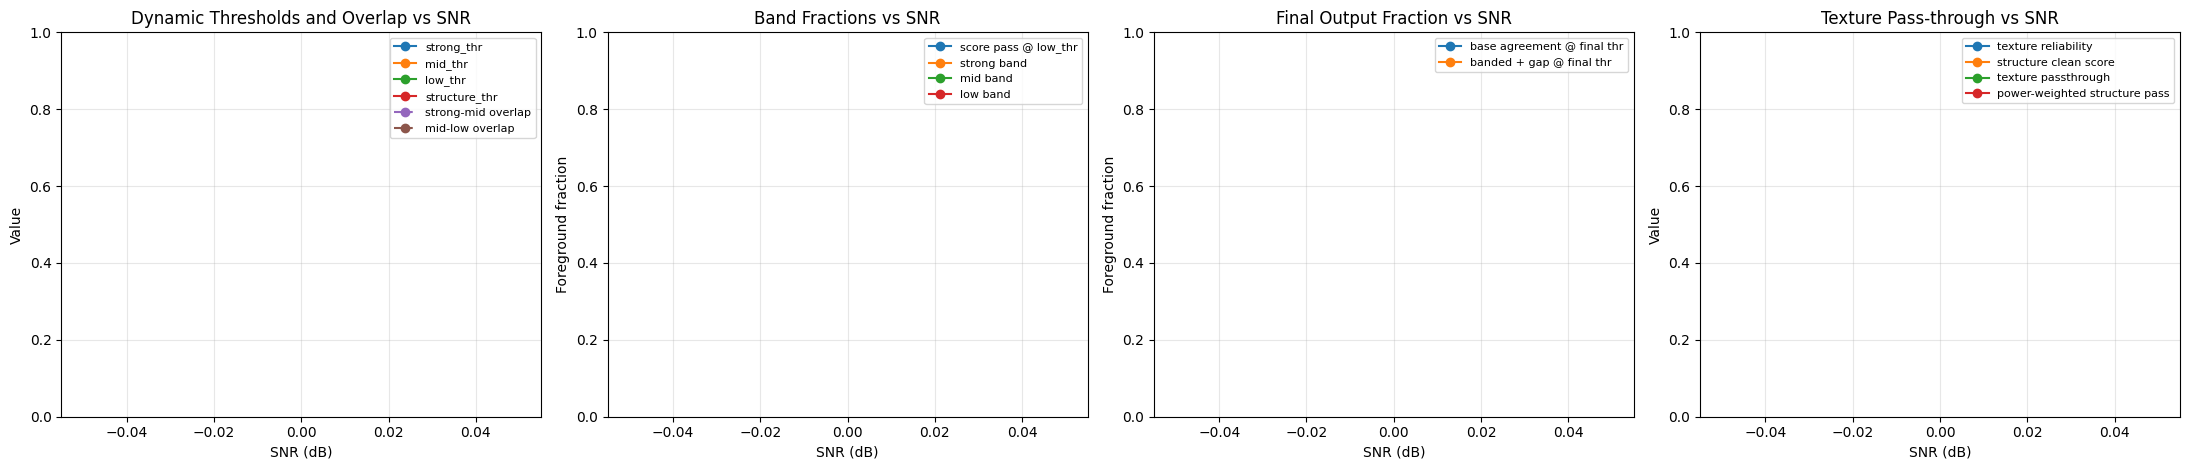

No pipeline visuals available for the selected PIPELINE_VISUAL_SNRS.
No overlay visuals available for the selected PIPELINE_VISUAL_SNRS.


In [35]:
# Banded-overlap revision: strong, mid, and low are now mostly separate bands with a small overlap.

def _build_multilevel_gap_pipeline_banded(
    score_map,
    structure_map,
    texture_map,
    reliability,
    gap_floor,
    raw_power_map=None,
    power_rescue_floor=PIPELINE_POWER_RESCUE_FLOOR,
    power_rescue_gain=PIPELINE_POWER_RESCUE_GAIN,
):
    score_map = np.asarray(score_map, dtype=np.float32)
    structure_map = np.asarray(structure_map, dtype=np.float32)
    texture_map = np.asarray(texture_map, dtype=np.float32)
    if raw_power_map is None:
        raw_power_map = np.zeros_like(score_map, dtype=np.float32)
    raw_power_map = np.asarray(raw_power_map, dtype=np.float32)

    strong_thr = float(0.44 + 0.12 * reliability)
    mid_thr = float(0.24 + 0.10 * reliability)
    low_thr = float(0.10 + 0.08 * reliability)
    structure_thr = float(0.45 + 0.12 * reliability)
    score_pass_gate = (score_map >= low_thr).astype(np.float32)

    strong_mid_overlap = float(np.clip(0.15 * max(strong_thr - mid_thr, 0.0), 0.012, 0.035))
    mid_low_overlap = float(np.clip(0.15 * max(mid_thr - low_thr, 0.0), 0.012, 0.030))
    mid_upper = float(min(1.0, strong_thr + strong_mid_overlap))
    low_upper = float(min(1.0, mid_thr + mid_low_overlap))

    raw_power_local_mean = ndi.uniform_filter(
        _normalize_map01_local(raw_power_map, 5.0, 95.0).astype(np.float32),
        size=3,
        mode='nearest',
    ).astype(np.float32)
    power_rescue_floor = float(np.clip(power_rescue_floor, 0.0, 0.99))
    power_rescue_gain = float(np.clip(power_rescue_gain, 0.0, 2.0))
    power_rescue_term = np.clip(
        (raw_power_local_mean - power_rescue_floor) / max(1.0 - power_rescue_floor, 1e-6),
        0.0,
        1.0,
    ).astype(np.float32)
    structure_rescue_span = float(max(structure_thr - low_thr, 0.05))
    power_weighted_structure = np.clip(
        structure_map + power_rescue_gain * structure_rescue_span * (score_pass_gate * power_rescue_term),
        0.0,
        1.0,
    ).astype(np.float32)

    strong_candidate_mask = (score_map >= strong_thr).astype(np.uint8)
    mid_candidate_mask = np.logical_and(score_map >= mid_thr, score_map < mid_upper).astype(np.uint8)
    raw_structure_candidate_mask = score_pass_gate.astype(np.uint8)
    power_rescue_mask = np.zeros_like(raw_structure_candidate_mask, dtype=np.uint8)
    low_candidate_mask = np.logical_and(score_map >= low_thr, score_map < low_upper).astype(np.uint8)

    strong_score = (1.00 * score_map * strong_candidate_mask.astype(np.float32)).astype(np.float32)
    mid_score = (1.00 * score_map * mid_candidate_mask.astype(np.float32)).astype(np.float32)
    low_candidate_score = (1.00 * score_map * low_candidate_mask.astype(np.float32)).astype(np.float32)

    texture_policy = _pipeline_structure_texture_passthrough(structure_map, reliability)
    gap_floor = float(np.clip(gap_floor, 0.0, 1.0))
    texture_weight = float(np.clip(texture_policy['texture_passthrough'], gap_floor, 1.0))
    texture_penalty_strength = float(1.0 - texture_weight)

    # Speckle-driven band combination:
    #   No speckle  (score >= 0.96)  -> all 3 bands additive, weights ramp to 1.0
    #   Mid speckle (0.50 <= score < 0.96) -> mid/low weight ramps 0.0 -> 1.0
    #   Strong speckle (score < 0.50) -> strong band only (mid/low weight = 0.0)
    _speckle_clean_thr  = 0.96
    _speckle_strong_thr = 0.50
    _speckle_score = float(texture_policy['structure_speckle_score'])
    _band_weight = float(np.clip(
        (_speckle_score - _speckle_strong_thr) / (_speckle_clean_thr - _speckle_strong_thr),
        0.0, 1.0,
    ))
    # Normalize per-band scores before combining so pipeline strength matches visualization
    _norm_strong = _normalize_map01_local(strong_score, 5.0, 95.0).astype(np.float32)
    _norm_mid    = _normalize_map01_local(mid_score, 5.0, 95.0).astype(np.float32)
    _norm_low    = _normalize_map01_local(low_candidate_score, 5.0, 95.0).astype(np.float32)
    combined_band_score = np.clip(
        _norm_strong + _band_weight * _norm_mid + _band_weight * _norm_low,
        0.0, 1.0,
    ).astype(np.float32)
    stacked_pre_gap = combined_band_score
    gap_weight = np.full_like(texture_map, texture_weight, dtype=np.float32)
    texture_passthrough_score = (texture_weight * texture_map * (1.0 - stacked_pre_gap)).astype(np.float32)
    pre_gap_score = np.clip(stacked_pre_gap + texture_passthrough_score, 0.0, 1.0).astype(np.float32)
    final_map = _normalize_map01_local(pre_gap_score, 5.0, 95.0).astype(np.float32)

    return {
        'strong_thr': strong_thr,
        'mid_thr': mid_thr,
        'low_thr': low_thr,
        'structure_thr': structure_thr,
        'power_rescue_floor': power_rescue_floor,
        'power_rescue_gain': power_rescue_gain,
        'strong_mid_overlap': strong_mid_overlap,
        'mid_low_overlap': mid_low_overlap,
        'mid_upper': mid_upper,
        'low_upper': low_upper,
        'strong_candidate_mask': strong_candidate_mask.astype(np.uint8),
        'mid_candidate_mask': mid_candidate_mask.astype(np.uint8),
        'raw_power_local_mean': raw_power_local_mean,
        'power_rescue_term': power_rescue_term,
        'power_weighted_structure': power_weighted_structure,
        'raw_structure_candidate_mask': raw_structure_candidate_mask.astype(np.uint8),
        'power_rescue_mask': power_rescue_mask.astype(np.uint8),
        'low_candidate_mask': low_candidate_mask.astype(np.uint8),
        'strong_score': strong_score,
        'mid_score': mid_score,
        'low_candidate_score': low_candidate_score,
        'stacked_pre_gap': stacked_pre_gap,
        'texture_passthrough_score': texture_passthrough_score,
        'pre_gap_score': pre_gap_score,
        'structure_speckle_score': float(texture_policy['structure_speckle_score']),
        'structure_peak_score': float(texture_policy['structure_peak_score']),
        'structure_clean_score': float(texture_policy['structure_clean_score']),
        'texture_passthrough': texture_weight,
        'texture_penalty_strength': texture_penalty_strength,
        'combined_band_score': combined_band_score,
        'band_weight': _band_weight,
        'gap_weight': gap_weight,
        'final_map': final_map,
    }


_build_multilevel_gap_pipeline = _build_multilevel_gap_pipeline_banded

pipeline_fixed_rows = []
pipeline_visuals = []
pipeline_overlay_visuals = []
pipeline_stage_rows = []

for result in sorted(snr_results, key=lambda row: row['snr_db'], reverse=True):
    dino_map = _normalize_map01_local(np.asarray(result['dino_score_map'], dtype=np.float32), 5.0, 95.0).astype(np.float32)
    power_map = _normalize_map01_local(np.asarray(result['power_score_map'], dtype=np.float32), 5.0, 95.0).astype(np.float32)
    raw_power_map = np.asarray(result['power_raw_score_map'], dtype=np.float32)
    texture_map = _normalize_map01_local(np.asarray(result['texture_score_map'], dtype=np.float32), 5.0, 95.0).astype(np.float32)
    structure_map = _normalize_map01_local(
        np.asarray(result.get('dino_coherence_gate_map', result['dino_score_map']), dtype=np.float32),
        5.0,
        95.0,
    ).astype(np.float32)

    agreement_map = np.sqrt(np.clip(dino_map * power_map, 0.0, None)).astype(np.float32)
    texture_reliability = _pipeline_texture_reliability(texture_map, agreement_map)
    pipeline = _build_multilevel_gap_pipeline(
        agreement_map,
        structure_map,
        texture_map,
        texture_reliability,
        gap_floor=PIPELINE_GAP_FLOOR,
        raw_power_map=raw_power_map,
    )

    score_pass_mask = (agreement_map >= float(pipeline['low_thr'])).astype(np.uint8)
    structure_pass_mask = (structure_map >= float(pipeline['structure_thr'])).astype(np.uint8)
    power_weighted_structure_pass_mask = (pipeline['power_weighted_structure'] >= float(pipeline['structure_thr'])).astype(np.uint8)
    structure_rescue_gain_mask = np.logical_and(
        power_weighted_structure_pass_mask == 1,
        structure_pass_mask == 0,
    ).astype(np.uint8)
    base_mask = _smooth_binary_label_map(
        (agreement_map >= PIPELINE_FINAL_THRESHOLD).astype(np.uint8),
        iters=1,
        min_component_size=PIPELINE_COMPONENT_MIN_SIZE,
    )
    # Apply threshold + component filtering only when strong speckle is present
    _speckle_active = float(pipeline['band_weight']) < 1.0
    _final_thr = PIPELINE_FINAL_THRESHOLD if _speckle_active else PIPELINE_FINAL_THRESHOLD_NO_SPECKLE
    _min_comp  = 10 if _speckle_active else PIPELINE_COMPONENT_MIN_SIZE_NO_SPECKLE
    final_mask = (pipeline['final_map'] >= _final_thr).astype(np.uint8)
    if _min_comp > 0:
        comp, n_comp = ndimage.label(final_mask)
        if n_comp > 0:
            sizes = ndimage.sum(final_mask, comp, index=np.arange(1, n_comp + 1))
            small_ids = np.where(np.array(sizes) < int(_min_comp))[0] + 1
            if len(small_ids) > 0:
                final_mask[np.isin(comp, small_ids)] = 0

    if result.get('has_annotations', False):
        base_metrics = binary_mask_metrics(base_mask, result['gt_mask'])
        final_metrics = binary_mask_metrics(final_mask, result['gt_mask'])
        base_gap_recall = _pipeline_gap_recall(base_mask, result['gt_mask'], result['texture_mask'])
        final_gap_recall = _pipeline_gap_recall(final_mask, result['gt_mask'], result['texture_mask'])
    else:
        base_metrics = None
        final_metrics = None
        base_gap_recall = np.nan
        final_gap_recall = np.nan

    pipeline_stage_rows.append({
        'snr_db': int(result['snr_db']),
        'actual_snr_db': float(result['actual_snr_db']),
        'texture_reliability': float(texture_reliability),
        'structure_speckle_score': float(pipeline['structure_speckle_score']),
        'structure_clean_score': float(pipeline['structure_clean_score']),
        'texture_passthrough': float(pipeline['texture_passthrough']),
        'band_weight': float(pipeline['band_weight']),
        'score_pass_fg': float(np.mean(score_pass_mask)),
        'structure_pass_fg': float(np.mean(structure_pass_mask)),
        'power_weighted_structure_pass_fg': float(np.mean(power_weighted_structure_pass_mask)),
        'structure_rescue_gain_fg': float(np.mean(structure_rescue_gain_mask)),
        'strong_candidate_fg': float(np.mean(pipeline['strong_candidate_mask'])),
        'mid_candidate_fg': float(np.mean(pipeline['mid_candidate_mask'])),
        'raw_structure_candidate_fg': float(np.mean(pipeline['raw_structure_candidate_mask'])),
        'power_rescue_fg': float(np.mean(pipeline['power_rescue_mask'])),
        'low_candidate_fg': float(np.mean(pipeline['low_candidate_mask'])),
        'base_fg': float(np.mean(base_mask)),
        'final_fg': float(np.mean(final_mask)),
    })

    pipeline_fixed_rows.append({
        'snr_db': int(result['snr_db']),
        'actual_snr_db': float(result['actual_snr_db']),
        'has_annotations': bool(result.get('has_annotations', False)),
        'texture_reliability': float(texture_reliability),
        'structure_clean_score': float(pipeline['structure_clean_score']),
        'texture_passthrough': float(pipeline['texture_passthrough']),
        'strong_thr': float(pipeline['strong_thr']),
        'mid_thr': float(pipeline['mid_thr']),
        'low_thr': float(pipeline['low_thr']),
        'structure_thr': float(pipeline['structure_thr']),
        'strong_mid_overlap': float(pipeline['strong_mid_overlap']),
        'mid_low_overlap': float(pipeline['mid_low_overlap']),
        'power_rescue_floor': float(pipeline['power_rescue_floor']),
        'power_rescue_gain': float(pipeline['power_rescue_gain']),
        'base_fg': float(np.mean(base_mask)),
        'multilevel_fg': float(np.mean(final_mask)),
        'base_f1': np.nan if base_metrics is None else float(base_metrics['f1']),
        'multilevel_f1': np.nan if final_metrics is None else float(final_metrics['f1']),
        'base_iou': np.nan if base_metrics is None else float(base_metrics['iou']),
        'multilevel_iou': np.nan if final_metrics is None else float(final_metrics['iou']),
        'base_gap_recall': float(base_gap_recall),
        'multilevel_gap_recall': float(final_gap_recall),
    })

    if result['snr_db'] in PIPELINE_VISUAL_SNRS:
        pipeline_visuals.append({
            'snr_db': int(result['snr_db']),
            'spec_img': result['spec_img'],
            'gt_mask': np.asarray(result['gt_mask'], dtype=np.uint8) if result.get('has_annotations', False) else np.zeros_like(result['texture_mask'], dtype=np.uint8),
            'maps': {
                'base_agreement': agreement_map,
                'structure_map': structure_map,
                'power_weighted_structure': pipeline['power_weighted_structure'],
                'strong_score': _normalize_map01_local(pipeline['strong_score'], 5.0, 95.0).astype(np.float32),
                'mid_score': _normalize_map01_local(pipeline['mid_score'], 5.0, 95.0).astype(np.float32),
                'low_candidate_score': _normalize_map01_local(pipeline['low_candidate_score'], 5.0, 95.0).astype(np.float32),
                'combined_band_score': pipeline['combined_band_score'],
                'texture_passthrough_score': _normalize_map01_local(pipeline['texture_passthrough_score'], 5.0, 95.0).astype(np.float32),
                'pre_gap_score': _normalize_map01_local(pipeline['pre_gap_score'], 5.0, 95.0).astype(np.float32),
                'gap_weight': pipeline['gap_weight'],
                'multilevel_gap': pipeline['final_map'],
                'final_mask': final_mask.astype(np.float32),
            },
        })

        pipeline_overlay_visuals.append({
            'snr_db': int(result['snr_db']),
            'spec_img': result['spec_img'],
            'score_pass_mask': score_pass_mask,
            'strong_candidate_mask': pipeline['strong_candidate_mask'],
            'mid_candidate_mask': pipeline['mid_candidate_mask'],
            'low_candidate_mask': pipeline['low_candidate_mask'],
            'structure_pass_mask': structure_pass_mask,
            'power_weighted_structure_pass_mask': power_weighted_structure_pass_mask,
            'raw_structure_candidate_mask': pipeline['raw_structure_candidate_mask'],
            'base_mask': base_mask,
            'final_mask': final_mask,
        })

pipeline_stage_df = pd.DataFrame(pipeline_stage_rows)
if pipeline_stage_df.empty:
    pipeline_stage_df = pd.DataFrame(columns=['snr_db', 'actual_snr_db', 'texture_reliability', 'structure_speckle_score', 'structure_clean_score', 'texture_passthrough', 'band_weight', 'score_pass_fg', 'structure_pass_fg', 'power_weighted_structure_pass_fg', 'structure_rescue_gain_fg', 'strong_candidate_fg', 'mid_candidate_fg', 'raw_structure_candidate_fg', 'power_rescue_fg', 'low_candidate_fg', 'base_fg', 'final_fg'])
else:
    pipeline_stage_df = pipeline_stage_df.sort_values('snr_db', ascending=False)
pipeline_fixed_df = pd.DataFrame(pipeline_fixed_rows)
if pipeline_fixed_df.empty:
    pipeline_fixed_df = pd.DataFrame(columns=['snr_db', 'actual_snr_db', 'has_annotations', 'texture_reliability', 'structure_clean_score', 'texture_passthrough', 'strong_thr', 'mid_thr', 'low_thr', 'structure_thr', 'strong_mid_overlap', 'mid_low_overlap', 'power_rescue_floor', 'power_rescue_gain', 'base_fg', 'multilevel_fg', 'base_f1', 'multilevel_f1', 'base_iou', 'multilevel_iou', 'base_gap_recall', 'multilevel_gap_recall'])
else:
    pipeline_fixed_df = pipeline_fixed_df.sort_values('snr_db', ascending=False)
has_gt = bool(pipeline_fixed_df['has_annotations'].any()) if 'has_annotations' in pipeline_fixed_df.columns and len(pipeline_fixed_df) else False

print('Banded pipeline comparison: strong, mid, and low now use mostly separate score bands with small overlap near the strong/mid and mid/low boundaries.')
display(pipeline_stage_df.round(3))
display(pipeline_fixed_df.round(3))

fig, ax = plt.subplots(1, 4, figsize=(22, 4.8))
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['strong_thr'], marker='o', label='strong_thr')
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['mid_thr'], marker='o', label='mid_thr')
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['low_thr'], marker='o', label='low_thr')
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['structure_thr'], marker='o', label='structure_thr')
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['strong_mid_overlap'], marker='o', linestyle='--', label='strong-mid overlap')
ax[0].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['mid_low_overlap'], marker='o', linestyle='--', label='mid-low overlap')
ax[0].set_title('Dynamic Thresholds and Overlap vs SNR')
ax[0].set_xlabel('SNR (dB)')
ax[0].set_ylabel('Value')
ax[0].set_ylim(0.0, 1.0)
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8)

ax[1].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['score_pass_fg'], marker='o', label='score pass @ low_thr')
ax[1].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['strong_candidate_fg'], marker='o', label='strong band')
ax[1].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['mid_candidate_fg'], marker='o', label='mid band')
ax[1].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['low_candidate_fg'], marker='o', label='low band')
ax[1].set_title('Band Fractions vs SNR')
ax[1].set_xlabel('SNR (dB)')
ax[1].set_ylabel('Foreground fraction')
ax[1].set_ylim(0.0, 1.0)
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8)

ax[2].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['base_fg'], marker='o', label='base agreement @ final thr')
ax[2].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['multilevel_fg'], marker='o', label='banded + gap @ final thr')
ax[2].set_title('Final Output Fraction vs SNR')
ax[2].set_xlabel('SNR (dB)')
ax[2].set_ylabel('Foreground fraction')
ax[2].set_ylim(0.0, 1.0)
ax[2].grid(True, alpha=0.3)
ax[2].legend(fontsize=8)

if has_gt:
    ax[3].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['base_f1'], marker='o', label='base F1')
    ax[3].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['multilevel_f1'], marker='o', label='banded F1')
    ax[3].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['base_gap_recall'], marker='o', label='base gap recall')
    ax[3].plot(pipeline_fixed_df['snr_db'], pipeline_fixed_df['multilevel_gap_recall'], marker='o', label='banded gap recall')
    ax[3].set_title('Banded Metrics vs SNR')
    ax[3].set_ylabel('Metric value')
else:
    ax[3].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['texture_reliability'], marker='o', label='texture reliability')
    ax[3].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['structure_clean_score'], marker='o', label='structure clean score')
    ax[3].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['texture_passthrough'], marker='o', label='texture passthrough')
    ax[3].plot(pipeline_stage_df['snr_db'], pipeline_stage_df['power_weighted_structure_pass_fg'], marker='o', label='power-weighted structure pass')
    ax[3].set_title('Texture Pass-through vs SNR')
    ax[3].set_ylabel('Value')
ax[3].set_xlabel('SNR (dB)')
ax[3].set_ylim(0.0, 1.0)
ax[3].grid(True, alpha=0.3)
ax[3].legend(fontsize=8)

plt.tight_layout()
plt.show()

pipeline_visuals = sorted(pipeline_visuals, key=lambda row: row['snr_db'], reverse=True)
if len(pipeline_visuals):
    fig, axes = plt.subplots(len(pipeline_visuals), 14, figsize=(50, 3.6 * len(pipeline_visuals)), constrained_layout=True)
    if len(pipeline_visuals) == 1:
        axes = np.expand_dims(axes, axis=0)

    ordered_titles = [
        ('spec', 'Exact DINO input'),
        ('gt_mask', 'Ground truth mask'),
        ('base_agreement', '1. Base agreement'),
        ('structure_map', '2. Structure diagnostic'),
        ('power_weighted_structure', '3. Power-weighted diagnostic'),
        ('strong_score', '4. Strong-band score'),
        ('mid_score', '5. Mid-band score'),
        ('low_candidate_score', '6. Low-band score'),
        ('combined_band_score', '7. Combined band score'),
        ('texture_passthrough_score', '8. Texture additive boost'),
        ('pre_gap_score', '9. Pre-gap blend'),
        ('gap_weight', '10. Texture weight'),
        ('multilevel_gap', '11. Final banded + gap'),
        ('final_mask', '12. Final mask'),
    ]

    for row_idx, row in enumerate(pipeline_visuals):
        cur_axes = axes[row_idx]
        cur_axes[0].imshow(row['spec_img'])
        cur_axes[0].set_title(f"SNR {row['snr_db']} dB\n{ordered_titles[0][1]}")
        cur_axes[1].imshow(_overlay_from_mask(row['spec_img'], row['gt_mask']))
        cur_axes[1].set_title(ordered_titles[1][1])

        for col_idx, (map_key, title) in enumerate(ordered_titles[2:], start=2):
            cur_axes[col_idx].imshow(row['maps'][map_key], cmap='magma', vmin=0.0, vmax=1.0, interpolation='nearest')
            cur_axes[col_idx].set_title(title)

        for cur_ax in cur_axes:
            cur_ax.axis('off')

    fig.colorbar(
        plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=0.0, vmax=1.0)),
        ax=axes[:, 2:14].ravel().tolist(),
        fraction=0.02,
        pad=0.01,
        label='Normalized contribution / score',
    )
    plt.show()
else:
    print('No pipeline visuals available for the selected PIPELINE_VISUAL_SNRS.')

pipeline_overlay_visuals = sorted(pipeline_overlay_visuals, key=lambda row: row['snr_db'], reverse=True)
if len(pipeline_overlay_visuals):
    fig, axes = plt.subplots(len(pipeline_overlay_visuals), 10, figsize=(34, 3.6 * len(pipeline_overlay_visuals)), constrained_layout=True)
    if len(pipeline_overlay_visuals) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, row in enumerate(pipeline_overlay_visuals):
        cur_axes = axes[row_idx]
        cur_axes[0].imshow(row['spec_img'])
        cur_axes[0].set_title(f"SNR {row['snr_db']} dB\nExact DINO input")
        cur_axes[1].imshow(_overlay_from_mask(row['spec_img'], row['score_pass_mask']))
        cur_axes[1].set_title('Score pass @ low_thr')
        cur_axes[2].imshow(_overlay_from_mask(row['spec_img'], row['strong_candidate_mask']))
        cur_axes[2].set_title('Strong band')
        cur_axes[3].imshow(_overlay_from_mask(row['spec_img'], row['mid_candidate_mask']))
        cur_axes[3].set_title('Mid band')
        cur_axes[4].imshow(_overlay_from_mask(row['spec_img'], row['low_candidate_mask']))
        cur_axes[4].set_title('Low band')
        cur_axes[5].imshow(_overlay_from_mask(row['spec_img'], row['structure_pass_mask']))
        cur_axes[5].set_title('Raw structure pass')
        cur_axes[6].imshow(_overlay_from_mask(row['spec_img'], row['power_weighted_structure_pass_mask']))
        cur_axes[6].set_title('Power-weighted structure pass')
        cur_axes[7].imshow(_overlay_from_mask(row['spec_img'], row['raw_structure_candidate_mask']))
        cur_axes[7].set_title('Low-thr gate')
        cur_axes[8].imshow(_overlay_from_mask(row['spec_img'], row['base_mask']))
        cur_axes[8].set_title(f'Base @ {PIPELINE_FINAL_THRESHOLD:.2f}')
        cur_axes[9].imshow(_overlay_from_mask(row['spec_img'], row['final_mask']))
        cur_axes[9].set_title(f'Banded + gap @ {PIPELINE_FINAL_THRESHOLD:.2f}')
        for cur_ax in cur_axes:
            cur_ax.axis('off')

    plt.show()
else:
    print('No overlay visuals available for the selected PIPELINE_VISUAL_SNRS.')